# Практическая работа № 4

In [213]:
import os

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, \
    mean_absolute_percentage_error
from sklearn.linear_model import Lasso, Ridge, ElasticNet, SGDRegressor
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
import optuna
import seaborn as sns

Для начала загрузим таблицу с информацией о результатах построения моделей в практической работе № 3.

In [169]:
practice3_results = pd.read_csv("datasets/practice3_results.csv", index_col=0)

practice3_results

,Train Data,Train Data.1,Train Data.2,Train Data.3,Train Data.4,Test Data,Test Data.1,Test Data.2,Test Data.3,Test Data.4
NaN,R2,MSE,RMSE,MAE,MAPE,R2,MSE,RMSE,MAE,MAPE
Linear regression without regularization,0.82,0.184,0.4289,0.3427,1.7935,0.81,0.1876,0.4331,0.3452,3.3207
Linear regression with Lasso regularization,0.82,0.1841,0.4291,0.3432,1.7848,0.81,0.1874,0.4329,0.3455,3.3022
Linear regression with Ridge regularization,0.82,0.1843,0.4293,0.3427,1.7413,0.81,0.1873,0.4327,0.3441,3.2156
Linear regression with Elastic Net (get with GridSearch),0.82,0.1841,0.429,0.343,1.7771,0.81,0.1873,0.4328,0.3451,3.2871
Linear regression with Elastic Net (get with RandomSearch),0.82,0.1841,0.429,0.3427,1.7629,0.81,0.1873,0.4328,0.3445,3.2592
Linear regression with Elastic Net (get with Optuna),0.82,0.1843,0.4293,0.3429,1.7385,0.81,0.1872,0.4327,0.3442,3.2094
Polynomial regression (deg 2) without regularization,0.93,0.0725,0.2692,0.2042,0.9169,0.92,0.0786,0.2803,0.2118,1.71
Polynomial regression (deg 3) without regularization,0.97,0.0335,0.1832,0.1282,0.5769,0.96,0.0397,0.1991,0.1381,0.6519
Polynomial regression (deg 4) without regularization,0.98,0.018,0.1343,0.0921,0.3423,0.97,0.0345,0.1856,0.1252,0.8196


Удалим первую строку из датафрайма и сделаем корректные имена столбцов

In [170]:
practice3_results.drop(practice3_results.index[0], axis=0, inplace=True)

metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([["Train Data", "Test Data"], metrics])
practice3_results.columns = columns
practice3_results

Train Data                  \
                                                           R2     MSE    RMSE   
Linear regression without regularization                 0.82   0.184  0.4289   
Linear regression with Lasso regularization              0.82  0.1841  0.4291   
Linear regression with Ridge regularization              0.82  0.1843  0.4293   
Linear regression with Elastic Net (get with Gr...       0.82  0.1841   0.429   
Linear regression with Elastic Net (get with Ra...       0.82  0.1841   0.429   
Linear regression with Elastic Net (get with Op...       0.82  0.1843  0.4293   
Polynomial regression (deg 2) without regulariz...       0.93  0.0725  0.2692   
Polynomial regression (deg 3) without regulariz...       0.97  0.0335  0.1832   
Polynomial regression (deg 4) without regulariz...       0.98   0.018  0.1343   
Polynomial regression(deg 2) with L1 (get with ...       0.93  0.0727  0.2697   
Polynomial regression(deg 2) with L1 (get with ...       0.91  0.0921  0.3035   
Polynomial regression(deg 2) with L1 (get with ...       0.93  0.0727  0.2697   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0726  0.2695   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0726  0.2695   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0725  0.2692   
Polynomial regression (deg 3) with L1 (GridSearch)       0.97  0.0349  0.1869   
Polynomial regression (deg 3) with L1 (RandomSe...       0.92  0.0814  0.2853   
Polynomial regression (deg 3) with L1 (Optuna)           0.97  0.0349  0.1869   
Polynomial regression (deg 3) with L2 (GridSearch)       0.97  0.0336  0.1832   
Polynomial regression (deg 3) with L2 (RandomSe...       0.97  0.0335  0.1832   
Polynomial regression (deg 3) with L2 (Optuna)           0.97  0.0335  0.1832   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0344  0.1854   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0345  0.1858   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0339  0.1841   
Polynomial regression (deg 4) with L1 (GridSearch)       0.98  0.0231  0.1519   
Polynomial regression (deg 4) with L1 (RandomSe...       0.91    0.09     0.3   
Polynomial regression (deg 4) with L1 (Optuna)           0.98  0.0231  0.1519   
Polynomial regression (deg 4) with L2 (GridSearch)       0.98  0.0181  0.1346   
Polynomial regression (deg 4) with L2 (RandomSe...       0.98  0.0182   0.135   
Polynomial regression (deg 4) with L2 (Optuna)           0.98   0.018  0.1343   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0225  0.1501   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0209  0.1445   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0208  0.1442   

                                                                   Test Data  \
                                                       MAE    MAPE        R2   
Linear regression without regularization            0.3427  1.7935      0.81   
Linear regression with Lasso regularization         0.3432  1.7848      0.81   
Linear regression with Ridge regularization         0.3427  1.7413      0.81   
Linear regression with Elastic Net (get with Gr...   0.343  1.7771      0.81   
Linear regression with Elastic Net (get with Ra...  0.3427  1.7629      0.81   
Linear regression with Elastic Net (get with Op...  0.3429  1.7385      0.81   
Polynomial regression (deg 2) without regulariz...  0.2042  0.9169      0.92   
Polynomial regression (deg 3) without regulariz...  0.1282  0.5769      0.96   
Polynomial regression (deg 4) without regulariz...  0.0921  0.3423      0.97   
Polynomial regression(deg 2) with L1 (get with ...  0.2046  0.9051      0.92   
Polynomial r

Создадим две таблицы для работы: первая - с тренировочными и валидационными выборками, а вторая - с тестовыми данными.

In [171]:
train_and_val_metrics_comparing_columns = pd.MultiIndex.from_product([["Train Data", "Val Data"], metrics])
train_and_val_metrics_comparing = pd.DataFrame(columns=train_and_val_metrics_comparing_columns)
train_and_val_metrics_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Val Data, R2), (Val Data, MSE), (Val Data, RMSE), (Val Data, MAE), (Val Data, MAPE)]
Index: []

In [172]:
test_metrics_columns = pd.MultiIndex.from_product([["Test Data"], metrics])
test_metrics_info = pd.DataFrame(columns=test_metrics_columns)
test_metrics_info

Empty DataFrame
Columns: [(Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

Для избежания дублирования кода используем некоторые кастомные функции

Функция для получения метрик `get_metrics`

In [173]:
def get_metrics(y_test, y_predicted, print_results=False):
    names_of_metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]
    results = [
        round(r2_score(y_test, y_predicted), 2),
        round(mean_squared_error(y_test, y_predicted), 4),
        round(root_mean_squared_error(y_test, y_predicted), 4),
        round(mean_absolute_error(y_test, y_predicted), 4),
        round(mean_absolute_percentage_error(y_test, y_predicted), 4)
    ]

    if print_results:
        for name, result in zip(names_of_metrics, results):
            print(f"{name}: {result}")

    return results

Функция для вставки метрик в таблицу с тренировочными и валидационными данными `input_metrics_into_the_train_val_table`

In [174]:
def input_metrics_into_the_train_val_table(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_val_y, y_val):
    val_metrics = get_metrics(y_val, predict_on_val_y)

    train_metrics = get_metrics(y_train, predict_on_train_y)

    train_and_val_metrics_comparing.loc[name_of_model] = train_metrics  + val_metrics

Функция для вставки метрик в таблицу с тестовыми данными `input_metrics_into_the_train_val_table`

In [175]:
def input_metrics_into_the_test_table(name_of_model,
                          predict_on_test_y, y_test):
    test_metrics = get_metrics(y_test, predict_on_test_y)

    test_metrics_info.loc[name_of_model] = test_metrics

Функция `train_models_with_reg ` используется для получения моделей с L1, L2 и ElasticNet регуляризациями с помощью GridSearch, RandomizedSearchCV и фреймворка Optuna.

In [176]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def train_models_with_reg(X_train, y_train, X_val, y_val, reg_config, degree=1):

    result={}

    pipeline = make_pipeline(StandardScaler(), PolynomialFeatures(degree=degree))

    X_train = pipeline.fit_transform(X_train)
    X_val = pipeline.transform(X_val)

    for name, reg_info in reg_config.items():

        param_grid = reg_info["param_grid"]
        type_of_reg = reg_info["reg"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            cv=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            random_state=42,
            cv=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            model = type_of_reg(**trial_params)
            model.fit(X_train, y_train)
            score = mean_squared_error(y_val, model.predict(X_val))
            return score

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        optuna_model = type_of_reg(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": make_pipeline(pipeline, grid_search_model.best_estimator_),
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": make_pipeline(pipeline, random_search_model.best_estimator_),
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": make_pipeline(pipeline, optuna_model),
            "best_params": study.best_params
        }

    return result

## Сохранение данных в программные переменные

### Разделение данных на тренировочную, валидационную и тестовую выборки

Разделим данные в пропорциях 80 - 10 - 10

In [177]:
data = pd.read_csv("datasets/practice3_dataset.csv", index_col=0)

X = data.drop("stab", axis=1)
y = data["stab"]

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5)

print(f"Количество объектов в общей выборке: {len(X)}\n"
      f"Количество объектов в тренировочной выборке: {len(X_train)}\n"
      f"Количество объектов в валидационной выборке: {len(X_val)}\n"
      f"Количество объектов в тестовой выборке: {len(X_test)}")

Количество объектов в общей выборке: 10000
Количество объектов в тренировочной выборке: 8000
Количество объектов в валидационной выборке: 1000
Количество объектов в тестовой выборке: 1000


### Модель множественной регрессии без регуляризации

In [178]:
pipelines = {}
multiple_regression = make_pipeline(StandardScaler(), LinearRegression())

multiple_regression.fit(X_train, y_train)

train_predict = multiple_regression.predict(X_train)
val_predict = multiple_regression.predict(X_val)
test_predict = multiple_regression.predict(X_test)

pipelines["Multiple regression"] = multiple_regression

input_metrics_into_the_train_val_table("Multiple regression",
                          train_predict, y_train,
                          val_predict, y_val)

input_metrics_into_the_test_table(f"Multiple regression", test_predict, y_test)

train_and_val_metrics_comparing.loc["Multiple regression"]

Train Data  R2       0.8200
            MSE      0.0003
            RMSE     0.0158
            MAE      0.0126
            MAPE    12.8742
Val Data    R2       0.8200
            MSE      0.0002
            RMSE     0.0155
            MAE      0.0125
            MAPE     7.6890
Name: Multiple regression, dtype: float64

Text(0.5, 1.0, 'Множественная регрессия без регуляризации')

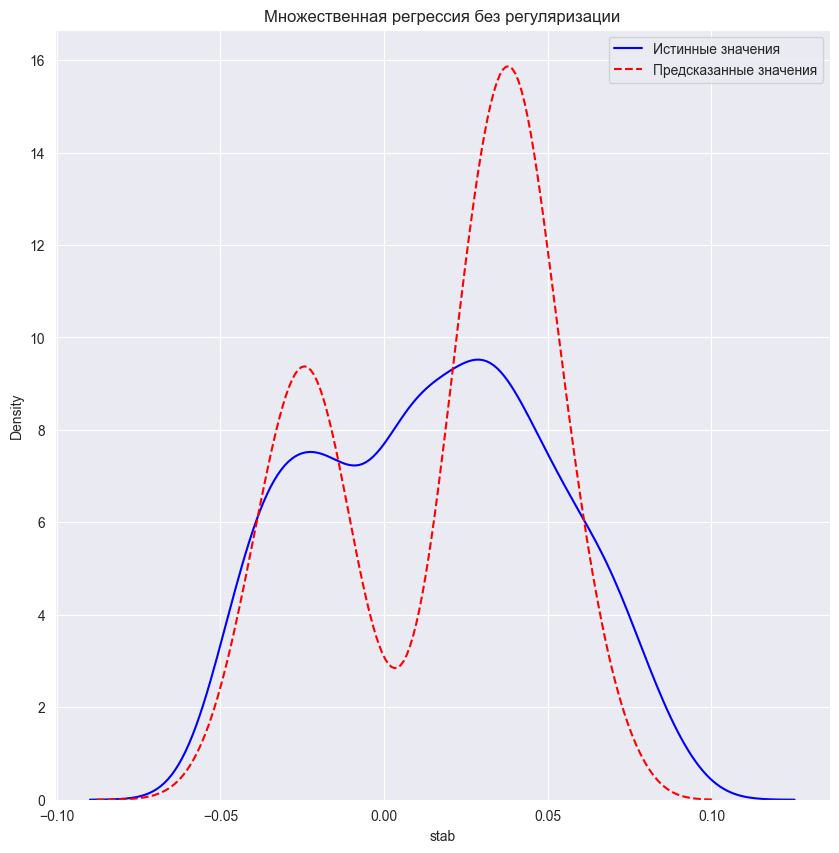

In [179]:
plt.figure(figsize=(10, 10))

sns.kdeplot(y_val, color="blue", label="Истинные значения")

sns.kdeplot(val_predict, linestyle="--", color="red", label="Предсказанные значения")

plt.grid(True)
plt.legend()
plt.title("Множественная регрессия без регуляризации")

Значения метрик неплохие. На валидационной выборке модель показала себя лучше, чем на тестовой выборке. Попробуем применить регуляризацию к модели

### Множественная регрессия с регуляризацией

In [180]:
alpha_range = np.logspace(-3, 2).tolist()
reg_config = {
    "L1": {
        "reg": Lasso,
        "param_grid": {"alpha": alpha_range}
    },
    "L2":
        {
            "reg": Ridge,
            "param_grid": {"alpha": alpha_range}
        },
    "EN":
        {
            "reg": ElasticNet,
            "param_grid":{
                    "alpha": alpha_range,
                    "l1_ratio": np.arange(0.1, 1, 0.3).tolist()
            }

        }

}

In [181]:
multiple_model_reg = train_models_with_reg(X_train, y_train, X_val, y_val, reg_config)
multiple_model_reg

{'L1': {'GridSearch': {'model': Pipeline(steps=[('pipeline',
                    Pipeline(steps=[('standardscaler', StandardScaler()),
                                    ('polynomialfeatures',
                                     PolynomialFeatures(degree=1))])),
                   ('lasso', Lasso(alpha=0.001))]),
   'best_params': {'alpha': 0.001}},
  'RandomSearch': {'model': Pipeline(steps=[('pipeline',
                    Pipeline(steps=[('standardscaler', StandardScaler()),
                                    ('polynomialfeatures',
                                     PolynomialFeatures(degree=1))])),
                   ('lasso', Lasso(alpha=0.021209508879201904))]),
   'best_params': {'alpha': 0.021209508879201904}},
  'Optuna': {'model': Pipeline(steps=[('pipeline',
                    Pipeline(steps=[('standardscaler', StandardScaler()),
                                    ('polynomialfeatures',
                                     PolynomialFeatures(degree=1))])),
           

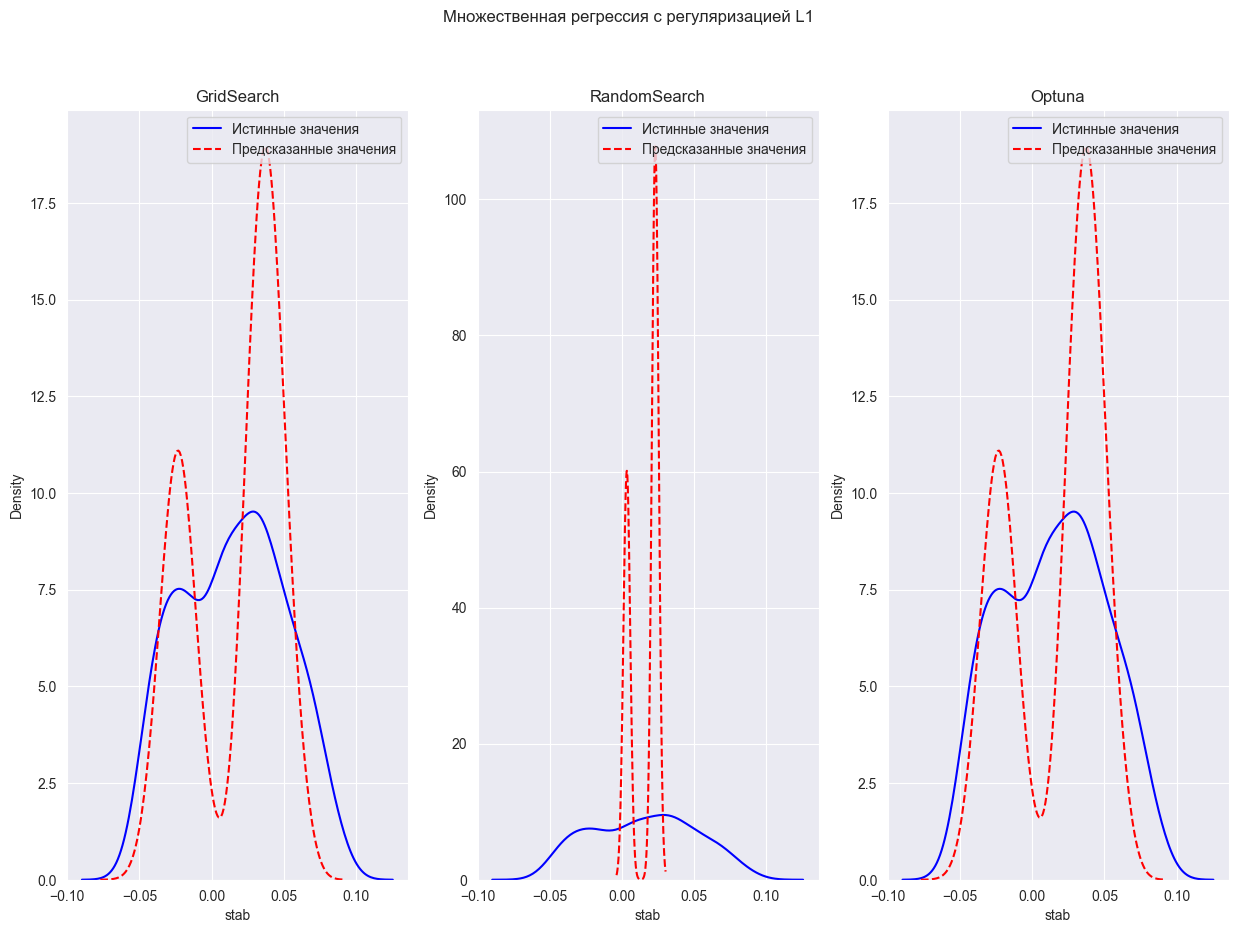

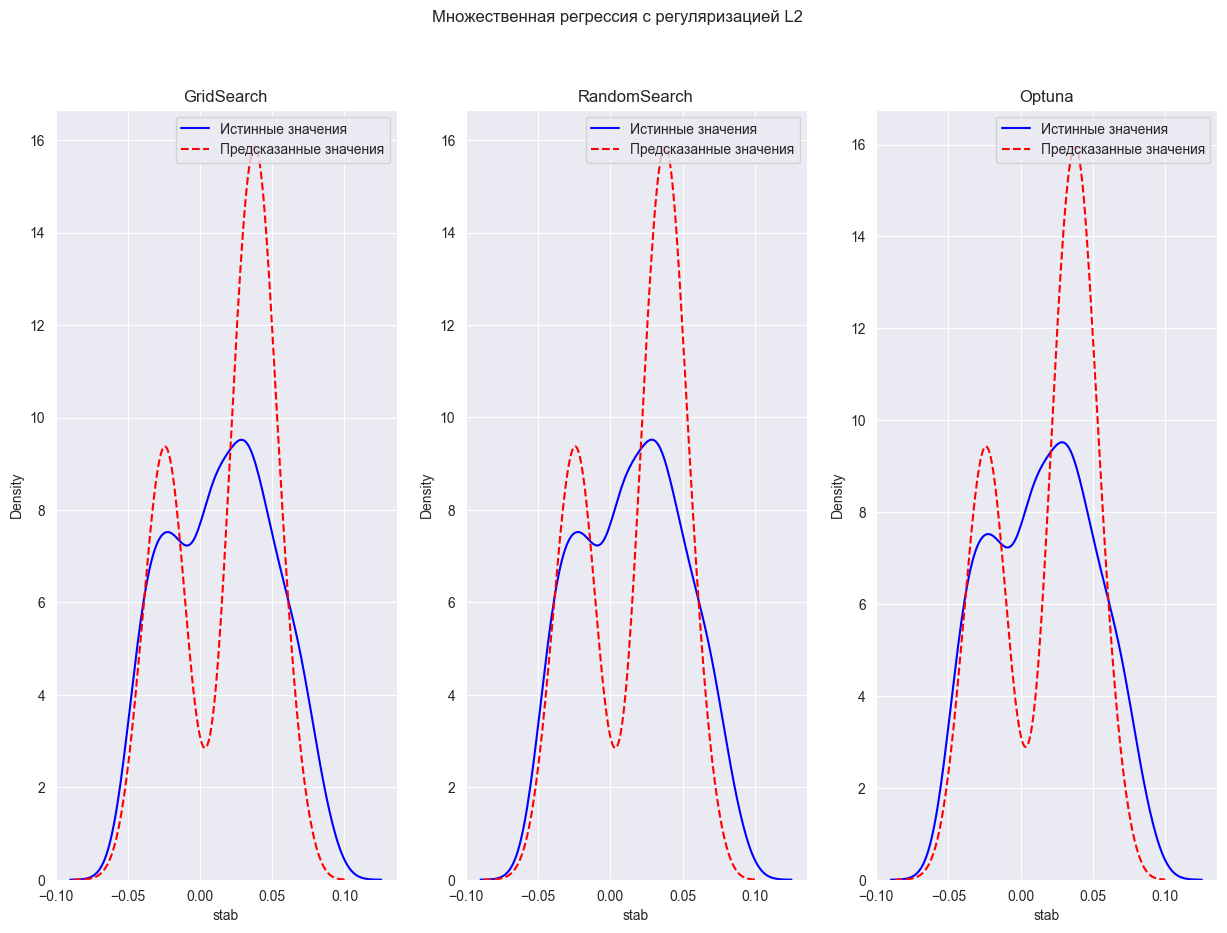

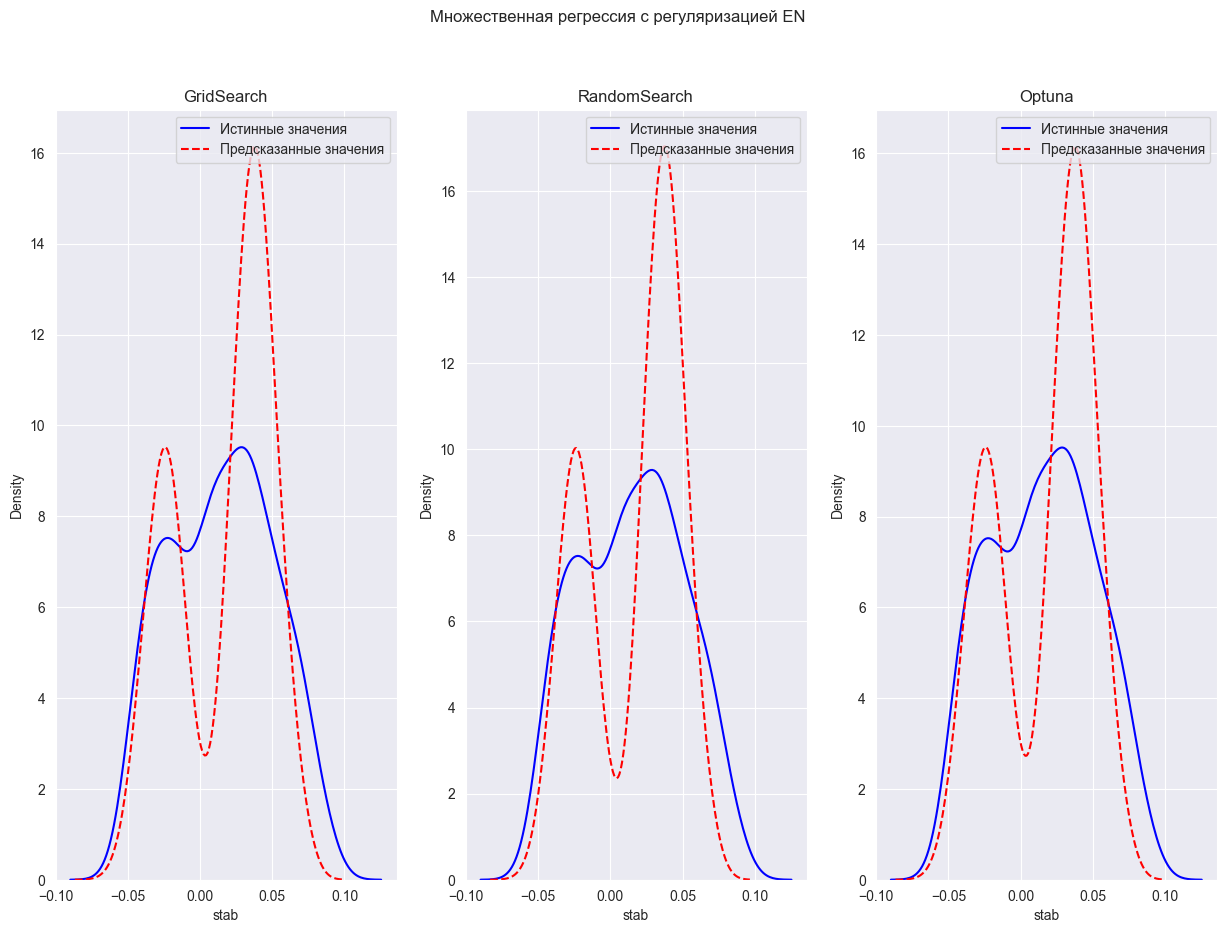

In [182]:
for name_of_reg, reg_info in multiple_model_reg.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 10))
    for (name_of_method, model_info), ax in zip(reg_info.items(), axes):
        model = model_info["model"]

        val_predict = model.predict(X_val)
        train_predict = model.predict(X_train)
        test_predict = model.predict(X_test)

        name = f"Multiple regression with {name_of_reg} ({name_of_method})"
        pipelines[name] = model

        input_metrics_into_the_train_val_table(name,
                          train_predict, y_train,
                          val_predict, y_val)

        input_metrics_into_the_test_table(name, test_predict, y_test)

        sns.kdeplot(y_val, color="blue", label="Истинные значения", ax=ax)

        sns.kdeplot(val_predict, linestyle="--", color="red", label="Предсказанные значения", ax=ax)

        ax.grid(True)
        ax.legend()
        ax.set_title(name_of_method)

    plt.suptitle(f"Множественная регрессия c регуляризацией {name_of_reg}")



Визуально регуляризация практически никак не изменила модель. Посмотрим на метрики

In [183]:
train_and_val_metrics_comparing

Train Data                          \
                                                   R2     MSE    RMSE     MAE   
Multiple regression                              0.82  0.0003  0.0158  0.0126   
Multiple regression with L1 (GridSearch)         0.81  0.0003  0.0161  0.0129   
Multiple regression with L1 (RandomSearch)       0.36  0.0009  0.0297  0.0245   
Multiple regression with L1 (Optuna)             0.81  0.0003  0.0161  0.0129   
Multiple regression with L2 (GridSearch)         0.82  0.0003  0.0158  0.0126   
Multiple regression with L2 (RandomSearch)       0.82  0.0003  0.0158  0.0126   
Multiple regression with L2 (Optuna)             0.82  0.0003  0.0158  0.0126   
Multiple regression with EN (GridSearch)         0.82  0.0003  0.0158  0.0126   
Multiple regression with EN (RandomSearch)       0.82  0.0003  0.0159  0.0127   
Multiple regression with EN (Optuna)             0.82  0.0003  0.0158  0.0126   

                                                    Val Data                  \
                                               MAPE       R2     MSE    RMSE   
Multiple regression                         12.8742     0.82  0.0002  0.0155   
Multiple regression with L1 (GridSearch)    14.2074     0.81  0.0002  0.0158   
Multiple regression with L1 (RandomSearch)  13.1111     0.36  0.0008  0.0289   
Multiple regression with L1 (Optuna)        14.2081     0.81  0.0002  0.0158   
Multiple regression with L2 (GridSearch)    12.8719     0.82  0.0002  0.0155   
Multiple regression with L2 (RandomSearch)  12.8733     0.82  0.0002  0.0155   
Multiple regression with L2 (Optuna)        12.8259     0.82  0.0002  0.0155   
Multiple regression with EN (GridSearch)    13.0330     0.82  0.0002  0.0155   
Multiple regression with EN (RandomSearch)  13.4133     0.81  0.0002  0.0156   
Multiple regression with EN (Optuna)        13.0388     0.82  0.0002  0.0155   

                                                            
                                               MAE    MAPE  
Multiple regression                         0.0125  7.6890  
Multiple regression with L1 (GridSearch)    0.0128  8.5576  
Multiple regression with L1 (RandomSearch)  0.0239  3.4552  
Multiple regression with L1 (Optuna)        0.0128  8.5581  
Multiple regression with L2 (GridSearch)    0.0125  7.6821  
Multiple regression with L2 (RandomSearch)  0.0125  7.6863  
Multiple regression with L2 (Optuna)        0.0125  7.5447  
Multiple regression with EN (GridSearch)    0.0125  7.7123  
Multiple regression with EN (RandomSearch)  0.0126  7.9566  
Multiple regression with EN (Optuna)        0.0125  7.7165

В целом регуляризация не улучшила модель.

### Полиномиальная регрессия 2 степени без регуляризации

In [184]:
poly2_model = make_pipeline(StandardScaler(), PolynomialFeatures(degree=2), LinearRegression())

poly2_model.fit(X_train, y_train)

name = "Polynomial regression (deg = 2)"
pipelines[name] = poly2_model

poly2_train_predict = poly2_model.predict(X_train)
poly2_val_predict = poly2_model.predict(X_val)
poly2_test_predict = poly2_model.predict(X_test)

input_metrics_into_the_train_val_table(name,
                          poly2_train_predict, y_train,
                          poly2_val_predict, y_val)

input_metrics_into_the_test_table(name, poly2_test_predict, y_test)

train_and_val_metrics_comparing

Train Data                          \
                                                   R2     MSE    RMSE     MAE   
Multiple regression                              0.82  0.0003  0.0158  0.0126   
Multiple regression with L1 (GridSearch)         0.81  0.0003  0.0161  0.0129   
Multiple regression with L1 (RandomSearch)       0.36  0.0009  0.0297  0.0245   
Multiple regression with L1 (Optuna)             0.81  0.0003  0.0161  0.0129   
Multiple regression with L2 (GridSearch)         0.82  0.0003  0.0158  0.0126   
Multiple regression with L2 (RandomSearch)       0.82  0.0003  0.0158  0.0126   
Multiple regression with L2 (Optuna)             0.82  0.0003  0.0158  0.0126   
Multiple regression with EN (GridSearch)         0.82  0.0003  0.0158  0.0126   
Multiple regression with EN (RandomSearch)       0.82  0.0003  0.0159  0.0127   
Multiple regression with EN (Optuna)             0.82  0.0003  0.0158  0.0126   
Polynomial regression (deg = 2)                  0.93  0.0001  0.0101  0.0076   

                                                    Val Data                  \
                                               MAPE       R2     MSE    RMSE   
Multiple regression                         12.8742     0.82  0.0002  0.0155   
Multiple regression with L1 (GridSearch)    14.2074     0.81  0.0002  0.0158   
Multiple regression with L1 (RandomSearch)  13.1111     0.36  0.0008  0.0289   
Multiple regression with L1 (Optuna)        14.2081     0.81  0.0002  0.0158   
Multiple regression with L2 (GridSearch)    12.8719     0.82  0.0002  0.0155   
Multiple regression with L2 (RandomSearch)  12.8733     0.82  0.0002  0.0155   
Multiple regression with L2 (Optuna)        12.8259     0.82  0.0002  0.0155   
Multiple regression with EN (GridSearch)    13.0330     0.82  0.0002  0.0155   
Multiple regression with EN (RandomSearch)  13.4133     0.81  0.0002  0.0156   
Multiple regression with EN (Optuna)        13.0388     0.82  0.0002  0.0155   
Polynomial regression (deg = 2)              3.5852     0.93  0.0001  0.0099   

                                                            
                                               MAE    MAPE  
Multiple regression                         0.0125  7.6890  
Multiple regression with L1 (GridSearch)    0.0128  8.5576  
Multiple regression with L1 (RandomSearch)  0.0239  3.4552  
Multiple regression with L1 (Optuna)        0.0128  8.5581  
Multiple regression with L2 (GridSearch)    0.0125  7.6821  
Multiple regression with L2 (RandomSearch)  0.0125  7.6863  
Multiple regression with L2 (Optuna)        0.0125  7.5447  
Multiple regression with EN (GridSearch)    0.0125  7.7123  
Multiple regression with EN (RandomSearch)  0.0126  7.9566  
Multiple regression with EN (Optuna)        0.0125  7.7165  
Polynomial regression (deg = 2)             0.0074  2.8266

Text(0.5, 1.0, 'Полиномиальная регрессия 2 степени без регуляризации')

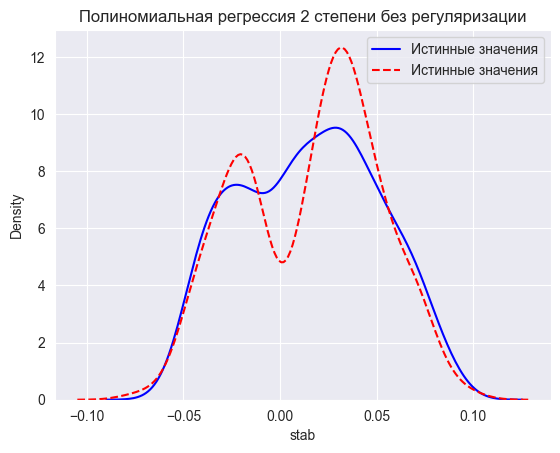

In [185]:
sns.kdeplot(y_val, color="blue", label="Истинные значения")
sns.kdeplot(poly2_val_predict, color="red", label="Истинные значения", linestyle="--")

plt.legend()
plt.grid(True)
plt.title("Полиномиальная регрессия 2 степени без регуляризации")

Полиномиальная регрессия 2 степени показала себя лучше, чем модели с линейными зависимостями (коэффициент R2 вырос до 0.92). Значения прочих метрик уменьшились - например, метрика RMSE равна 0.0101.

Стоит отметить, что на валидационной выборке значения метрик немного хуже, чем на тренировочной. Так, R2 на валидационной выборке равен 0.92, а на тренировочной 0.93. Разница не достататочно велика для того, чтобы говорить о наличии переобучения в модели.

### Полиномиальная регрессия 3 степени без регуляризации

In [186]:
poly3_model = make_pipeline(StandardScaler(), PolynomialFeatures(degree=3), LinearRegression())
poly3_model.fit(X_train, y_train)

poly3_train_predict = poly3_model.predict(X_train)
poly3_val_predict = poly3_model.predict(X_val)
poly3_test_predict = poly3_model.predict(X_test)

name = "Polynomial regression (deg = 3)"
pipelines[name] = poly3_model



input_metrics_into_the_train_val_table(name,
                          poly3_train_predict, y_train,
                          poly3_val_predict, y_val)

input_metrics_into_the_test_table(name, poly3_test_predict, y_test)

train_and_val_metrics_comparing

Train Data                          \
                                                   R2     MSE    RMSE     MAE   
Multiple regression                              0.82  0.0003  0.0158  0.0126   
Multiple regression with L1 (GridSearch)         0.81  0.0003  0.0161  0.0129   
Multiple regression with L1 (RandomSearch)       0.36  0.0009  0.0297  0.0245   
Multiple regression with L1 (Optuna)             0.81  0.0003  0.0161  0.0129   
Multiple regression with L2 (GridSearch)         0.82  0.0003  0.0158  0.0126   
Multiple regression with L2 (RandomSearch)       0.82  0.0003  0.0158  0.0126   
Multiple regression with L2 (Optuna)             0.82  0.0003  0.0158  0.0126   
Multiple regression with EN (GridSearch)         0.82  0.0003  0.0158  0.0126   
Multiple regression with EN (RandomSearch)       0.82  0.0003  0.0159  0.0127   
Multiple regression with EN (Optuna)             0.82  0.0003  0.0158  0.0126   
Polynomial regression (deg = 2)                  0.93  0.0001  0.0101  0.0076   
Polynomial regression (deg = 3)                  0.97  0.0000  0.0068  0.0047   

                                                    Val Data                  \
                                               MAPE       R2     MSE    RMSE   
Multiple regression                         12.8742     0.82  0.0002  0.0155   
Multiple regression with L1 (GridSearch)    14.2074     0.81  0.0002  0.0158   
Multiple regression with L1 (RandomSearch)  13.1111     0.36  0.0008  0.0289   
Multiple regression with L1 (Optuna)        14.2081     0.81  0.0002  0.0158   
Multiple regression with L2 (GridSearch)    12.8719     0.82  0.0002  0.0155   
Multiple regression with L2 (RandomSearch)  12.8733     0.82  0.0002  0.0155   
Multiple regression with L2 (Optuna)        12.8259     0.82  0.0002  0.0155   
Multiple regression with EN (GridSearch)    13.0330     0.82  0.0002  0.0155   
Multiple regression with EN (RandomSearch)  13.4133     0.81  0.0002  0.0156   
Multiple regression with EN (Optuna)        13.0388     0.82  0.0002  0.0155   
Polynomial regression (deg = 2)              3.5852     0.93  0.0001  0.0099   
Polynomial regression (deg = 3)              1.4855     0.96  0.0001  0.0072   

                                                            
                                               MAE    MAPE  
Multiple regression                         0.0125  7.6890  
Multiple regression with L1 (GridSearch)    0.0128  8.5576  
Multiple regression with L1 (RandomSearch)  0.0239  3.4552  
Multiple regression with L1 (Optuna)        0.0128  8.5581  
Multiple regression with L2 (GridSearch)    0.0125  7.6821  
Multiple regression with L2 (RandomSearch)  0.0125  7.6863  
Multiple regression with L2 (Optuna)        0.0125  7.5447  
Multiple regression with EN (GridSearch)    0.0125  7.7123  
Multiple regression with EN (RandomSearch)  0.0126  7.9566  
Multiple regression with EN (Optuna)        0.0125  7.7165  
Polynomial regression (deg = 2)             0.0074  2.8266  
Polynomial regression (deg = 3)             0.0050  4.7046

Text(0.5, 1.0, 'Полиномиальная регрессия 3 степени без регуляризации')

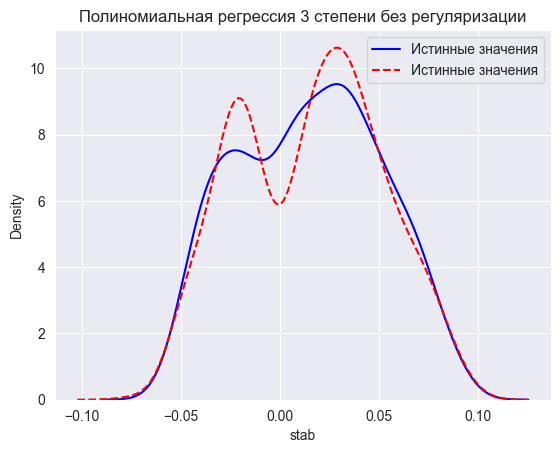

In [187]:
sns.kdeplot(y_val, color="blue", label="Истинные значения")
sns.kdeplot(poly3_val_predict, color="red", label="Истинные значения", linestyle="--")

plt.legend()
plt.grid(True)
plt.title("Полиномиальная регрессия 3 степени без регуляризации")

Полиномиальная регрессия 3 степени показала себя еще лучше, чем полиномиальная регрессия 2 степени (коэффициент R2 вырос до 0.97 на тренировочных данных и до 0.96 на валидационных).

### Полиномиальная регрессия 4 степени без регуляризации

In [188]:
poly4_model = make_pipeline(StandardScaler(), PolynomialFeatures(degree=4), LinearRegression())
poly4_model.fit(X_train, y_train)

poly4_train_predict = poly4_model.predict(X_train)
poly4_val_predict = poly4_model.predict(X_val)
poly4_test_predict = poly4_model.predict(X_test)

name = "Polynomial regression (deg = 4)"
pipelines[name] = poly4_model

input_metrics_into_the_train_val_table(name,
                          poly4_train_predict, y_train,
                          poly4_val_predict, y_val)

input_metrics_into_the_test_table(name, poly4_test_predict, y_test)

train_and_val_metrics_comparing

Train Data                          \
                                                   R2     MSE    RMSE     MAE   
Multiple regression                              0.82  0.0003  0.0158  0.0126   
Multiple regression with L1 (GridSearch)         0.81  0.0003  0.0161  0.0129   
Multiple regression with L1 (RandomSearch)       0.36  0.0009  0.0297  0.0245   
Multiple regression with L1 (Optuna)             0.81  0.0003  0.0161  0.0129   
Multiple regression with L2 (GridSearch)         0.82  0.0003  0.0158  0.0126   
Multiple regression with L2 (RandomSearch)       0.82  0.0003  0.0158  0.0126   
Multiple regression with L2 (Optuna)             0.82  0.0003  0.0158  0.0126   
Multiple regression with EN (GridSearch)         0.82  0.0003  0.0158  0.0126   
Multiple regression with EN (RandomSearch)       0.82  0.0003  0.0159  0.0127   
Multiple regression with EN (Optuna)             0.82  0.0003  0.0158  0.0126   
Polynomial regression (deg = 2)                  0.93  0.0001  0.0101  0.0076   
Polynomial regression (deg = 3)                  0.97  0.0000  0.0068  0.0047   
Polynomial regression (deg = 4)                  0.98  0.0000  0.0049  0.0034   

                                                    Val Data                  \
                                               MAPE       R2     MSE    RMSE   
Multiple regression                         12.8742     0.82  0.0002  0.0155   
Multiple regression with L1 (GridSearch)    14.2074     0.81  0.0002  0.0158   
Multiple regression with L1 (RandomSearch)  13.1111     0.36  0.0008  0.0289   
Multiple regression with L1 (Optuna)        14.2081     0.81  0.0002  0.0158   
Multiple regression with L2 (GridSearch)    12.8719     0.82  0.0002  0.0155   
Multiple regression with L2 (RandomSearch)  12.8733     0.82  0.0002  0.0155   
Multiple regression with L2 (Optuna)        12.8259     0.82  0.0002  0.0155   
Multiple regression with EN (GridSearch)    13.0330     0.82  0.0002  0.0155   
Multiple regression with EN (RandomSearch)  13.4133     0.81  0.0002  0.0156   
Multiple regression with EN (Optuna)        13.0388     0.82  0.0002  0.0155   
Polynomial regression (deg = 2)              3.5852     0.93  0.0001  0.0099   
Polynomial regression (deg = 3)              1.4855     0.96  0.0001  0.0072   
Polynomial regression (deg = 4)              0.6192     0.97  0.0000  0.0066   

                                                            
                                               MAE    MAPE  
Multiple regression                         0.0125  7.6890  
Multiple regression with L1 (GridSearch)    0.0128  8.5576  
Multiple regression with L1 (RandomSearch)  0.0239  3.4552  
Multiple regression with L1 (Optuna)        0.0128  8.5581  
Multiple regression with L2 (GridSearch)    0.0125  7.6821  
Multiple regression with L2 (RandomSearch)  0.0125  7.6863  
Multiple regression with L2 (Optuna)        0.0125  7.5447  
Multiple regression with EN (GridSearch)    0.0125  7.7123  
Multiple regression with EN (RandomSearch)  0.0126  7.9566  
Multiple regression with EN (Optuna)        0.0125  7.7165  
Polynomial regression (deg = 2)             0.0074  2.8266  
Polynomial regression (deg = 3)             0.0050  4.7046  
Polynomial regression (deg = 4)             0.0044  3.4673

Полиномиальная регрессия 4 степени показала себя лучше прочих моделей на тренировочной и валидационной выборках.

Стоит отметить, что на тренировочных данных модель показывает лучшие метрики, чем на валидационной выборке. Так, коэффициент R2 равен 0.98 на тренировочных данных и 0.96 на валидационных. Метрика RMSE равна 0.0049 на тренировочных данных и 0.0070 на валидационных. Это говорит о том, что, несмотря на высокий показатель степени, переобучения модели нет.

Text(0.5, 1.0, 'Полиномиальная регрессия 4 степени без регуляризации')

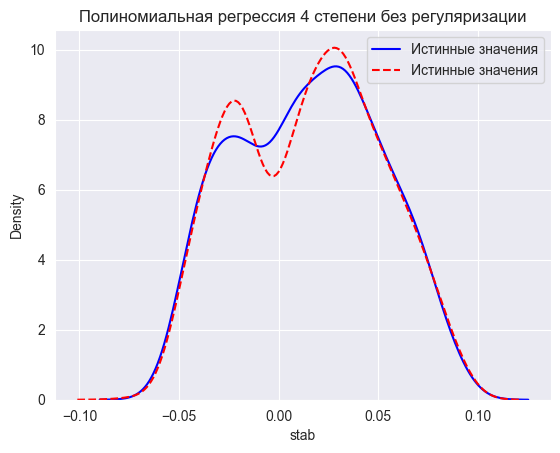

In [189]:
sns.kdeplot(y_val, color="blue", label="Истинные значения")
sns.kdeplot(poly4_val_predict, color="red", label="Истинные значения", linestyle="--")

plt.legend()
plt.grid(True)
plt.title("Полиномиальная регрессия 4 степени без регуляризации")

### Полиномиальные модели с регуляризацией

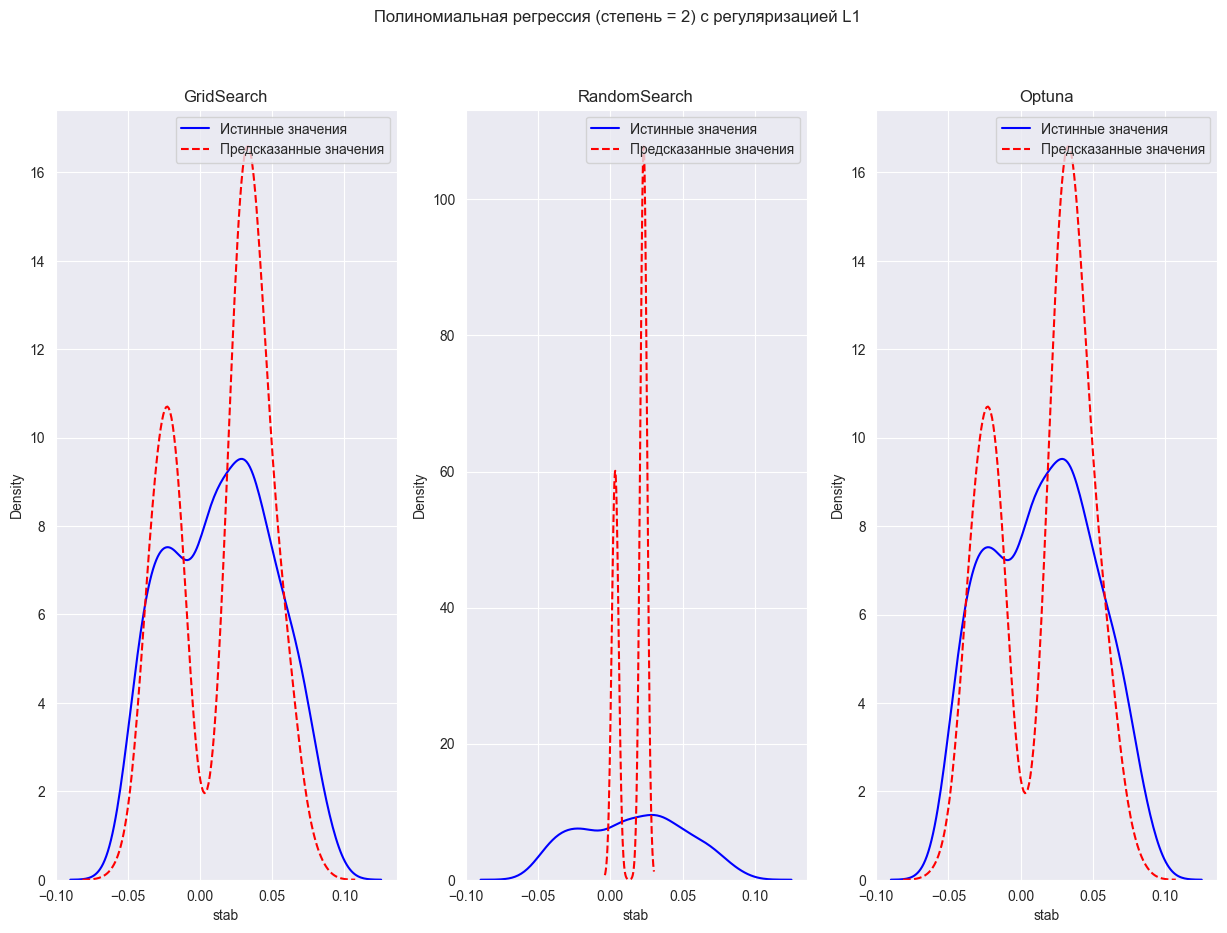

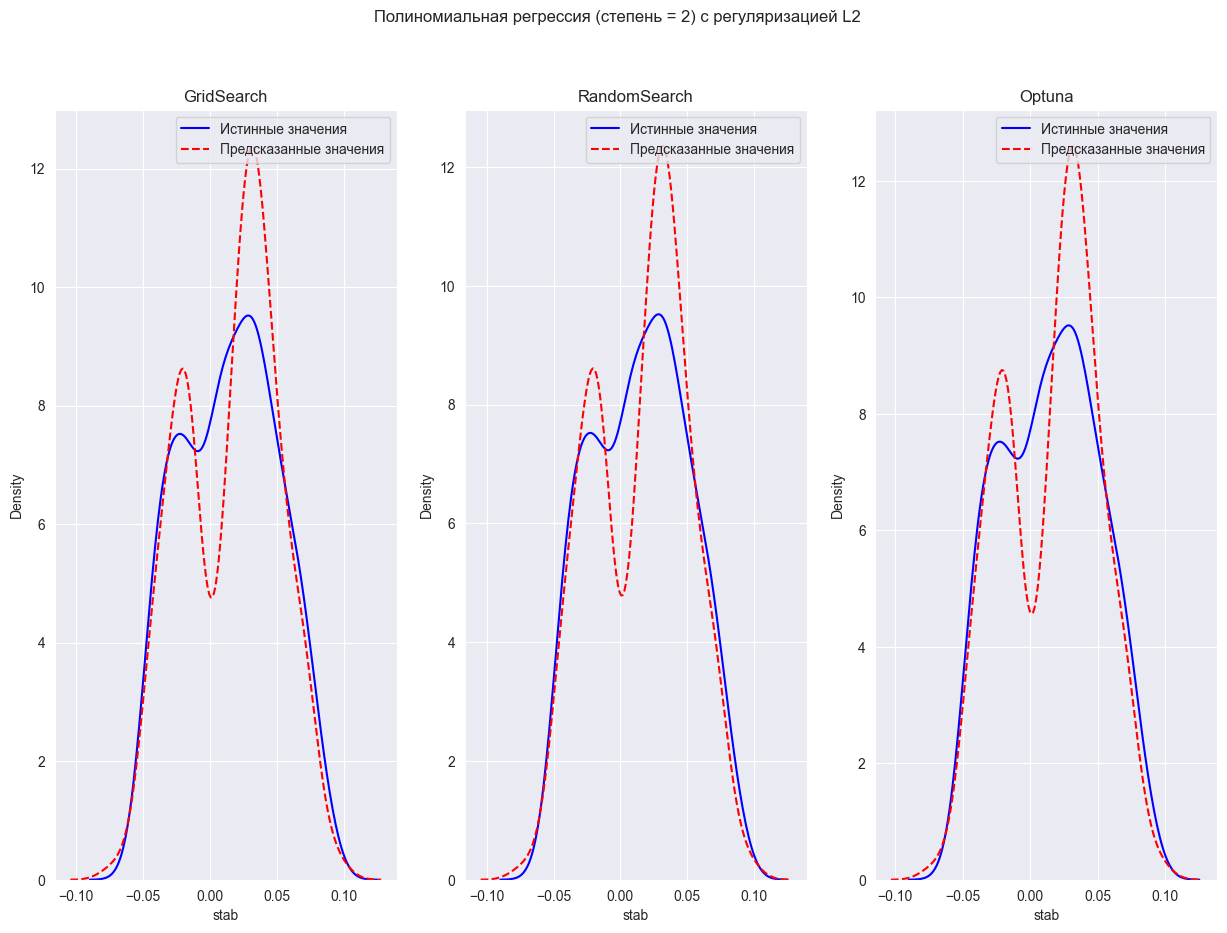

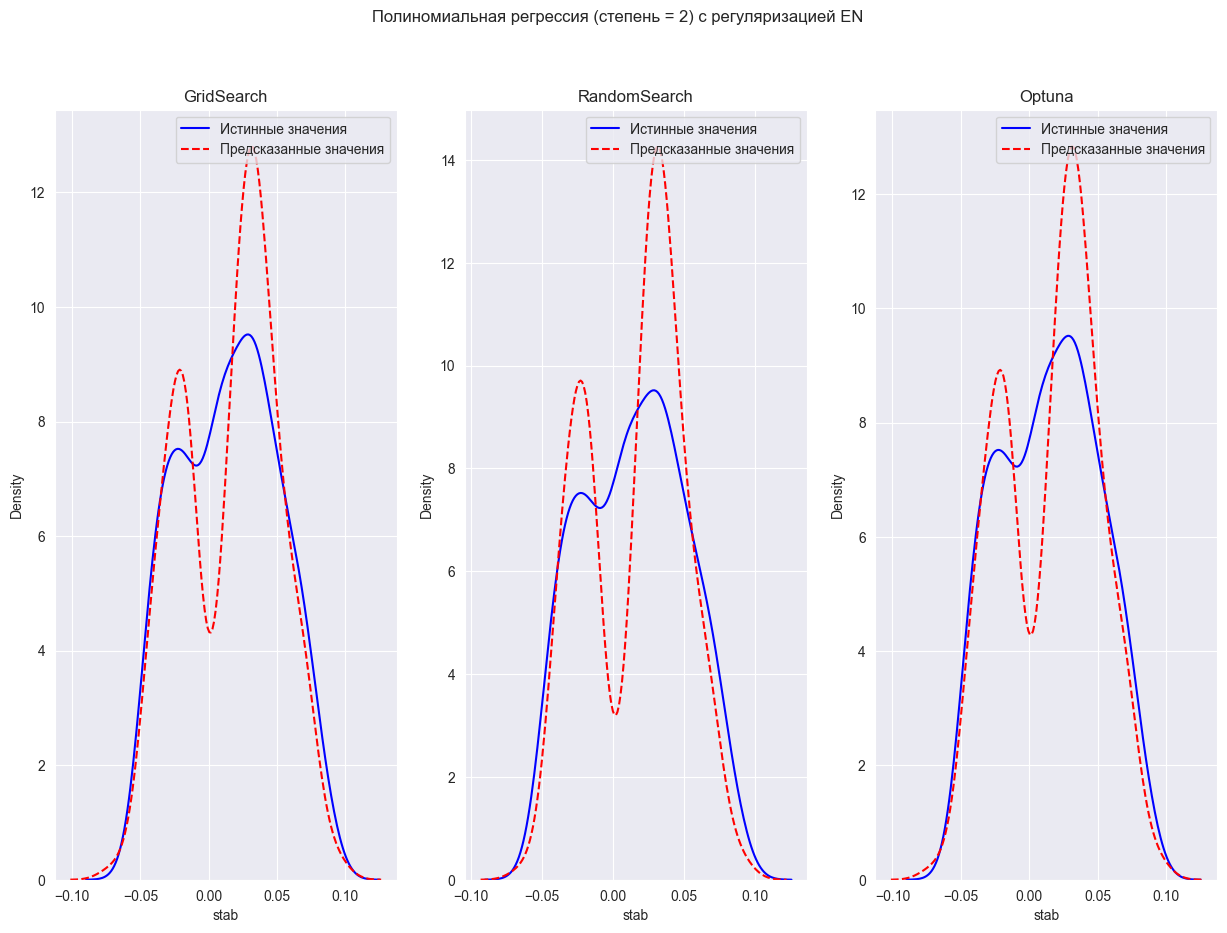

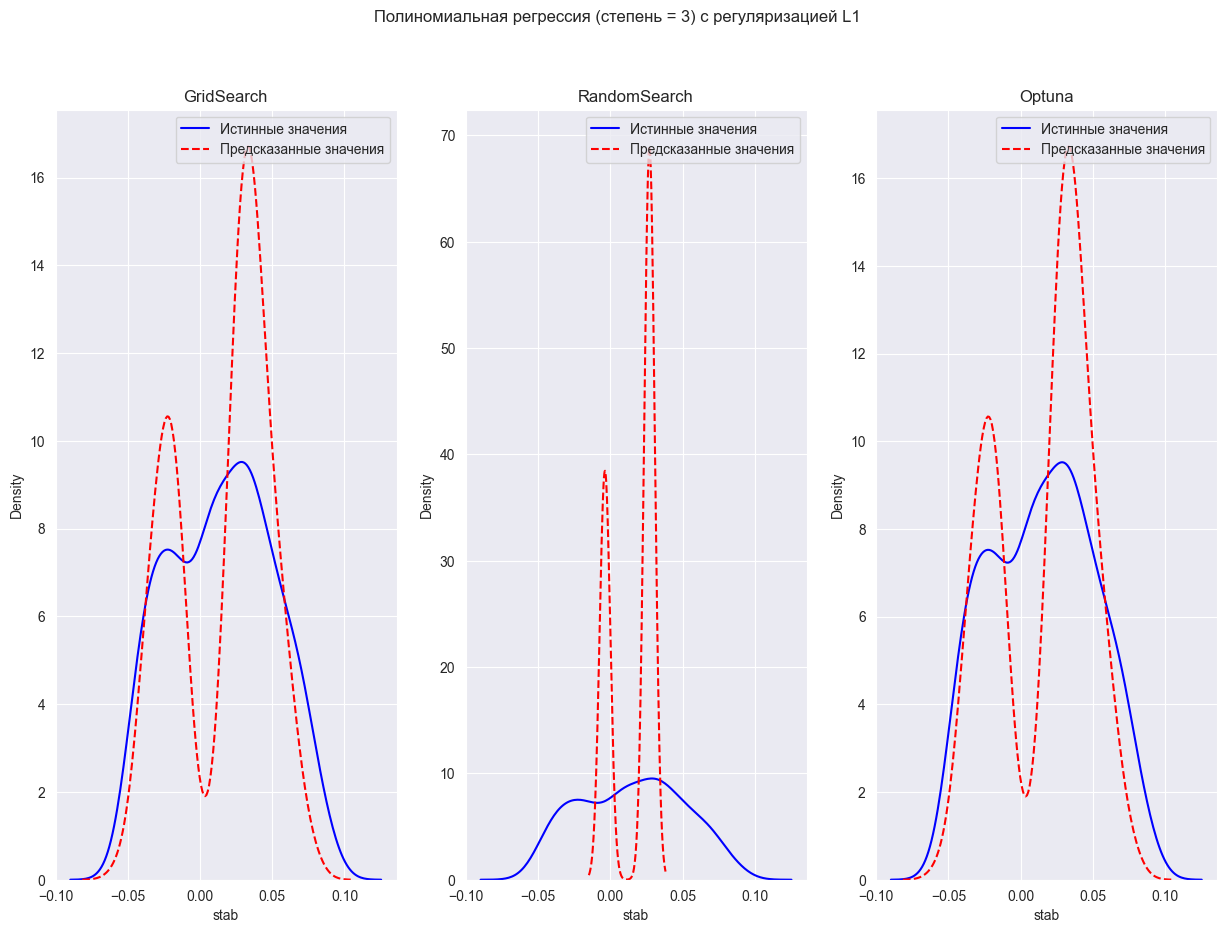

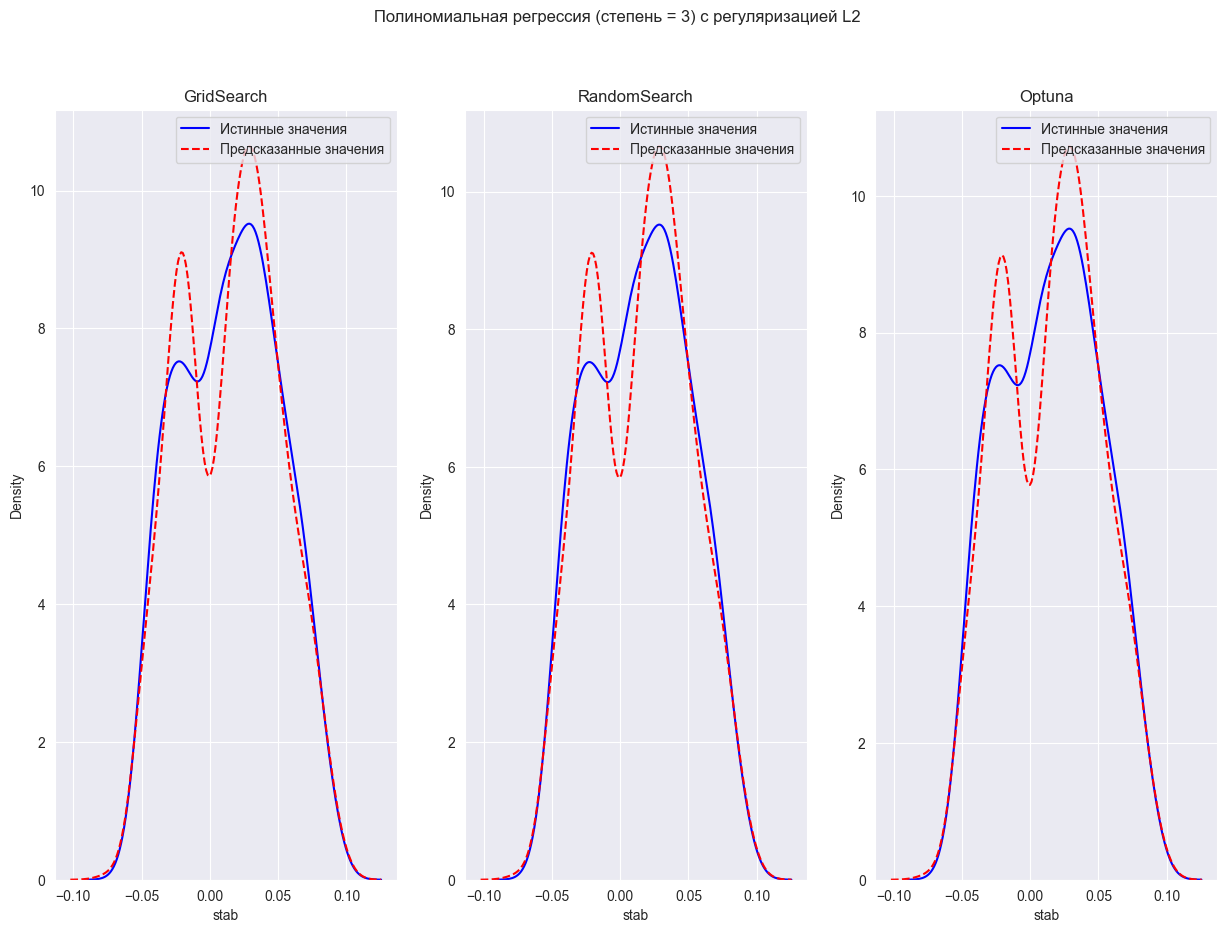

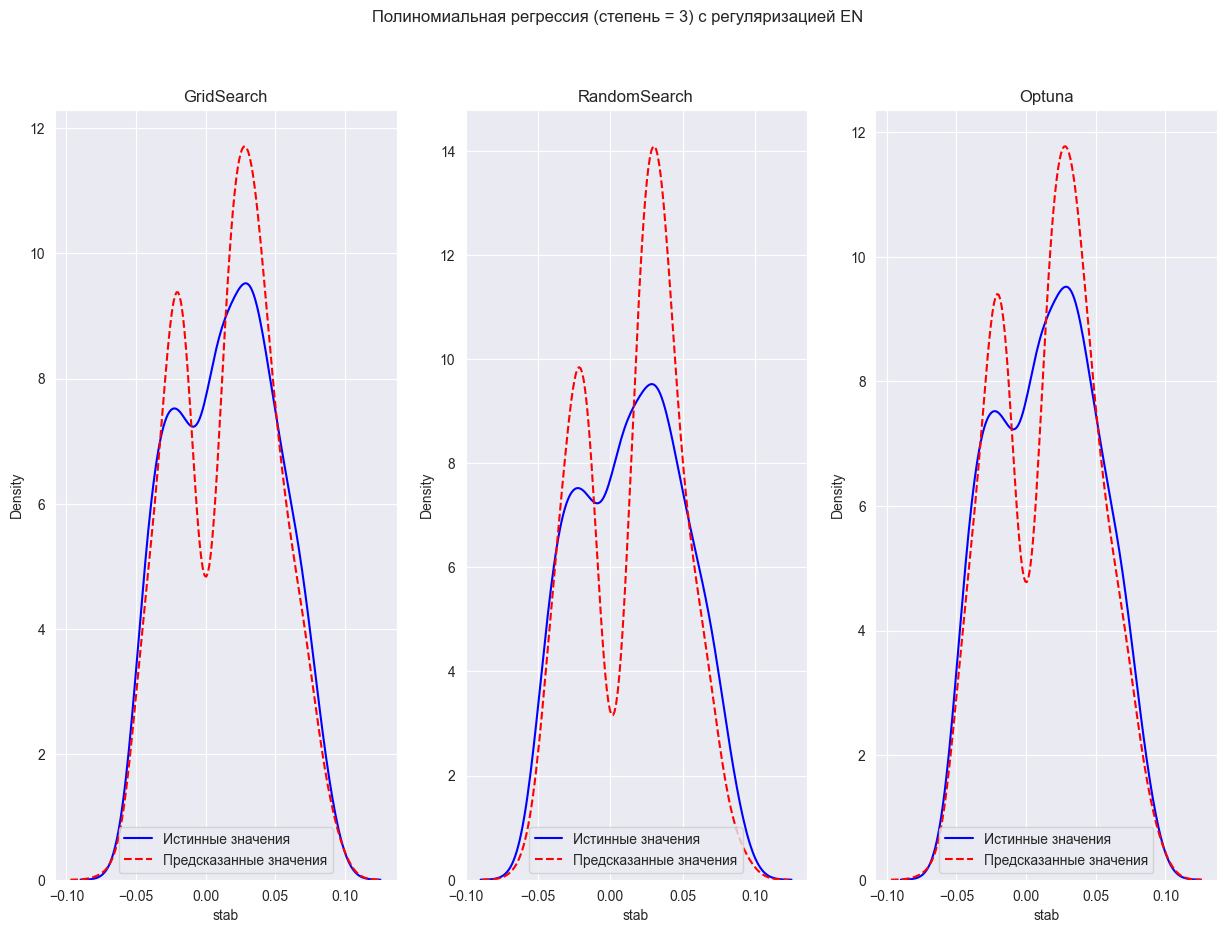

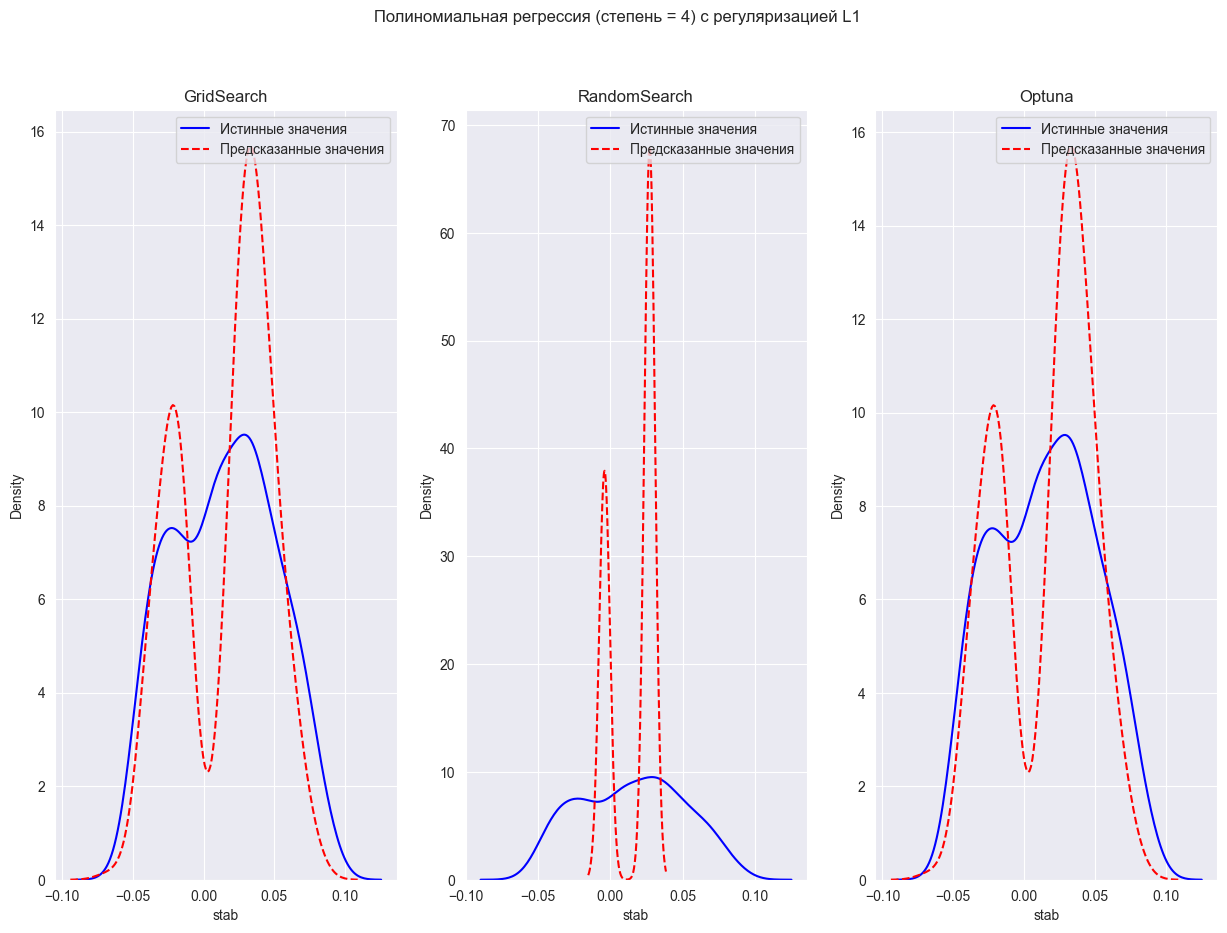

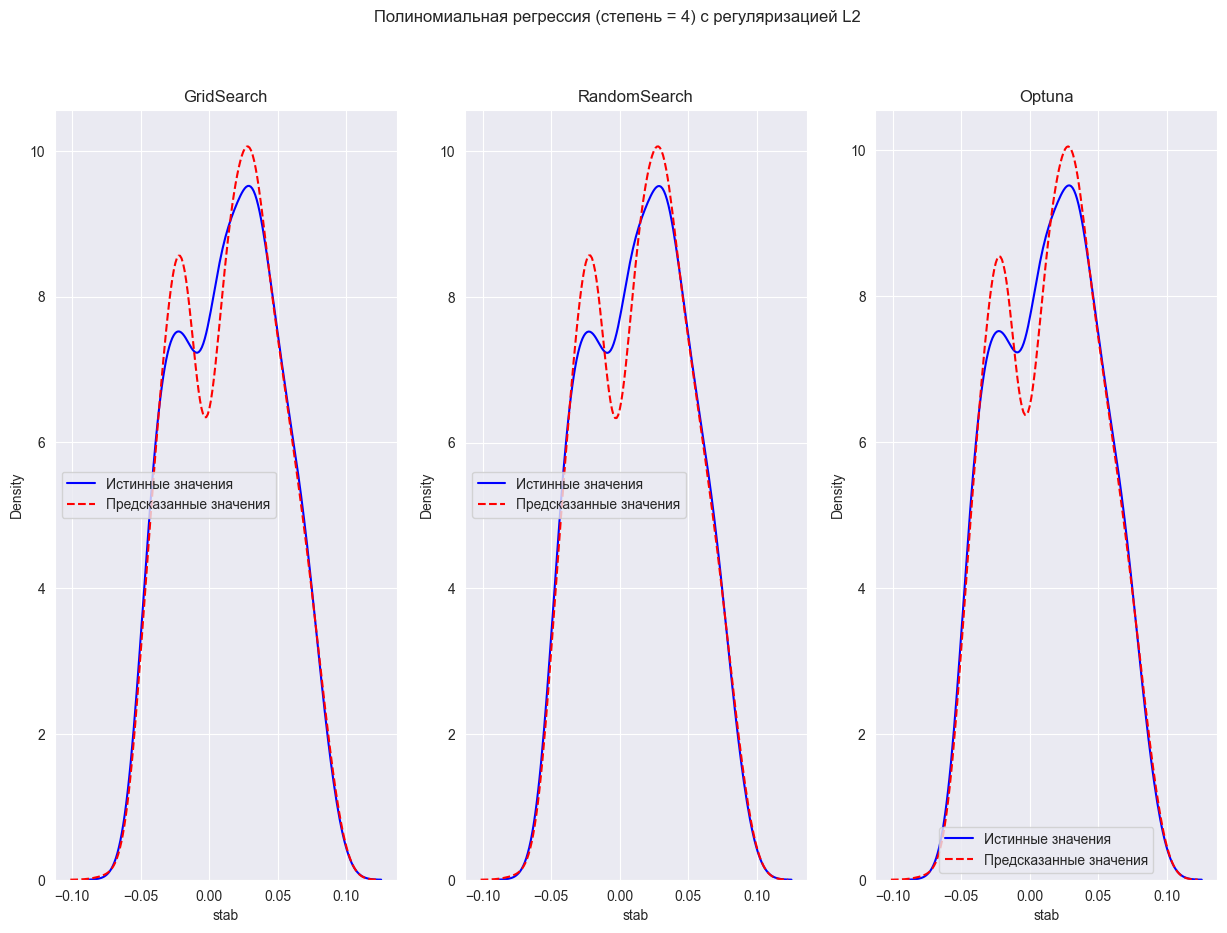

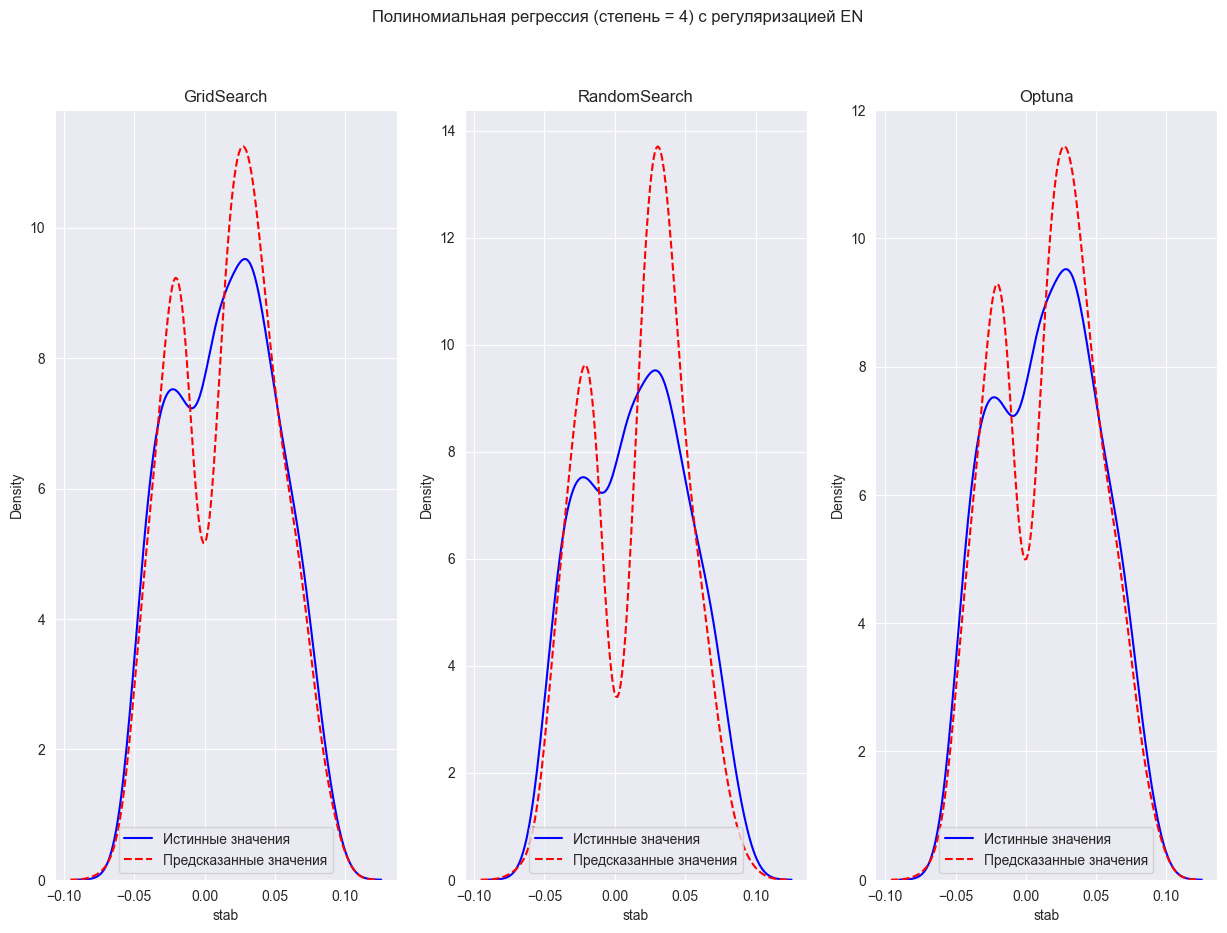

In [190]:
for degree in range(2, 5):
    poly_reg_models = train_models_with_reg(X_train, y_train, X_val, y_val, reg_config, degree=degree)

    for name_of_reg, reg_info in poly_reg_models.items():
        fig, axes = plt.subplots(1, 3, figsize=(15, 10))

        for (name_of_method, model_info), ax in zip(reg_info.items(), axes):
            model = model_info["model"]
            name = f"Polynomial regression (deg = {degree}) with {name_of_reg} ({name_of_method})"

            val_predict = model.predict(X_val)
            train_predict = model.predict(X_train)
            test_predict = model.predict(X_test)

            pipelines[name] = model

            input_metrics_into_the_train_val_table(name,  train_predict, y_train, val_predict, y_val)

            input_metrics_into_the_test_table(name, test_predict, y_test)

            sns.kdeplot(y_val, color="blue", label="Истинные значения", ax=ax)

            sns.kdeplot(val_predict, linestyle="--", color="red", label="Предсказанные значения", ax=ax)

            ax.grid(True)
            ax.legend()
            ax.set_title(name_of_method)

        plt.suptitle(f"Полиномиальная регрессия (степень = {degree}) c регуляризацией {name_of_reg}")



In [191]:
train_and_val_metrics_comparing[train_and_val_metrics_comparing.index.str.startswith("Polynomial")]

Train Data                  \
                                                           R2     MSE    RMSE   
Polynomial regression (deg = 2)                          0.93  0.0001  0.0101   
Polynomial regression (deg = 3)                          0.97  0.0000  0.0068   
Polynomial regression (deg = 4)                          0.98  0.0000  0.0049   
Polynomial regression (deg = 2) with L1 (GridSe...       0.90  0.0001  0.0120   
Polynomial regression (deg = 2) with L1 (Random...       0.36  0.0009  0.0297   
Polynomial regression (deg = 2) with L1 (Optuna)         0.90  0.0001  0.0120   
Polynomial regression (deg = 2) with L2 (GridSe...       0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with L2 (Random...       0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with L2 (Optuna)         0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with EN (GridSe...       0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with EN (Random...       0.92  0.0001  0.0107   
Polynomial regression (deg = 2) with EN (Optuna)         0.93  0.0001  0.0101   
Polynomial regression (deg = 3) with L1 (GridSe...       0.89  0.0001  0.0122   
Polynomial regression (deg = 3) with L1 (Random...       0.50  0.0007  0.0262   
Polynomial regression (deg = 3) with L1 (Optuna)         0.89  0.0001  0.0122   
Polynomial regression (deg = 3) with L2 (GridSe...       0.97  0.0000  0.0068   
Polynomial regression (deg = 3) with L2 (Random...       0.97  0.0000  0.0068   
Polynomial regression (deg = 3) with L2 (Optuna)         0.97  0.0000  0.0068   
Polynomial regression (deg = 3) with EN (GridSe...       0.96  0.0001  0.0072   
Polynomial regression (deg = 3) with EN (Random...       0.94  0.0001  0.0091   
Polynomial regression (deg = 3) with EN (Optuna)         0.96  0.0001  0.0072   
Polynomial regression (deg = 4) with L1 (GridSe...       0.89  0.0001  0.0122   
Polynomial regression (deg = 4) with L1 (Random...       0.51  0.0007  0.0260   
Polynomial regression (deg = 4) with L1 (Optuna)         0.89  0.0001  0.0122   
Polynomial regression (deg = 4) with L2 (GridSe...       0.98  0.0000  0.0049   
Polynomial regression (deg = 4) with L2 (Random...       0.98  0.0000  0.0049   
Polynomial regression (deg = 4) with L2 (Optuna)         0.98  0.0000  0.0049   
Polynomial regression (deg = 4) with EN (GridSe...       0.97  0.0000  0.0063   
Polynomial regression (deg = 4) with EN (Random...       0.94  0.0001  0.0092   
Polynomial regression (deg = 4) with EN (Optuna)         0.97  0.0000  0.0065   

                                                                    Val Data  \
                                                       MAE     MAPE       R2   
Polynomial regression (deg = 2)                     0.0076   3.5852     0.93   
Polynomial regression (deg = 3)                     0.0047   1.4855     0.96   
Polynomial regression (deg = 4)                     0.0034   0.6192     0.97   
Polynomial regression (deg = 2) with L1 (GridSe...  0.0096   8.1766     0.90   
Polynomial regression (deg = 2) with L1 (Random...  0.0245  13.1111     0.36   
Polynomial regression (deg = 2) with L1 (Optuna)    0.0096   8.1785     0.90   
Polynomial regression (deg = 2) with L2 (GridSe...  0.0076   3.4834     0.93   
Polynomial regression (deg = 2) with L2 (Random...  0.0076   3.5347     0.93   
Polynomial regression (deg = 2) with L2 (Optuna)    0.0077   3.0799     0.93   
Polynomial regression (deg = 2) with EN (GridSe...  0.0077   2.3889     0.93   
Polynomial regression (deg = 2) with EN (Random...  0.0084   4.4817     0.92   
Polynomial regression (deg = 2) with EN (Optuna)    0.0077   2.3110     0.93   
Polynomial regression (deg = 3) with L1 (GridSe...  0.0098   8.6136     0.89   
Polynomial regression (deg = 3) with L1 (Random...  0.0212  15.0817     0.51   
Polynomial regression (deg = 3) with L1 (Optuna)    0.0098   8.6310     0.89   
Polynomial regression (deg = 3) with L2 (GridSe...  0.0047   1.4275     0.96   
Polynomial regress

После применения регуляризации лучшей моделью осталась полиномиальная модель 4 степени, так как ее метрики MSE, RMSE, MAPE и MAE принимают наименьшие значения на валидационных данных.

### SGD регрессор

In [192]:
sgd_regressor = make_pipeline(StandardScaler(), SGDRegressor())

sgd_regressor.fit(X_train, y_train)

train_predict = sgd_regressor.predict(X_train)
val_predict = sgd_regressor.predict(X_val)
test_predict = sgd_regressor.predict(X_test)

name = "SGD regression"
pipelines[name] = sgd_regressor

input_metrics_into_the_train_val_table(name,
                          train_predict, y_train,
                          val_predict, y_val)

input_metrics_into_the_test_table(name, test_predict, y_test)

Text(0.5, 1.0, 'SGD регрессия без регуляризации')

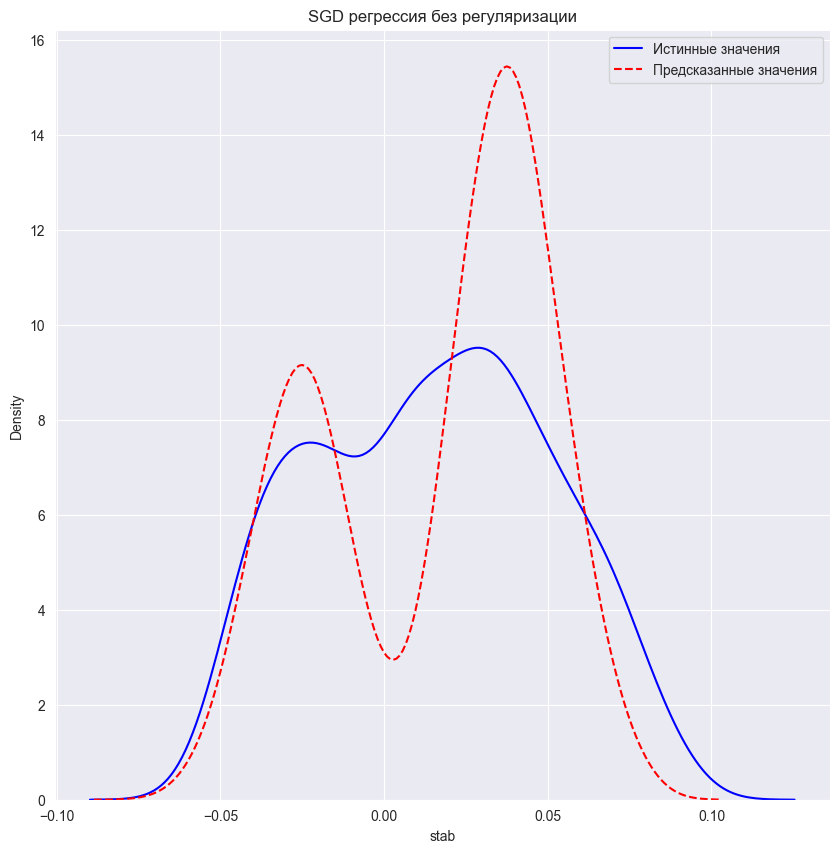

In [193]:
plt.figure(figsize=(10, 10))

sns.kdeplot(y_val, color="blue", label="Истинные значения")

sns.kdeplot(val_predict, linestyle="--", color="red", label="Предсказанные значения")

plt.grid(True)
plt.legend()
plt.title("SGD регрессия без регуляризации")

In [194]:
train_and_val_metrics_comparing.loc["SGD regression"]

Train Data  R2       0.8200
            MSE      0.0003
            RMSE     0.0159
            MAE      0.0126
            MAPE    13.0081
Val Data    R2       0.8100
            MSE      0.0002
            RMSE     0.0156
            MAE      0.0125
            MAPE     7.1294
Name: SGD regression, dtype: float64

В целом SGD регрессор неплохо работает, но его метрики хуже метрик для полиномиальной регрессии

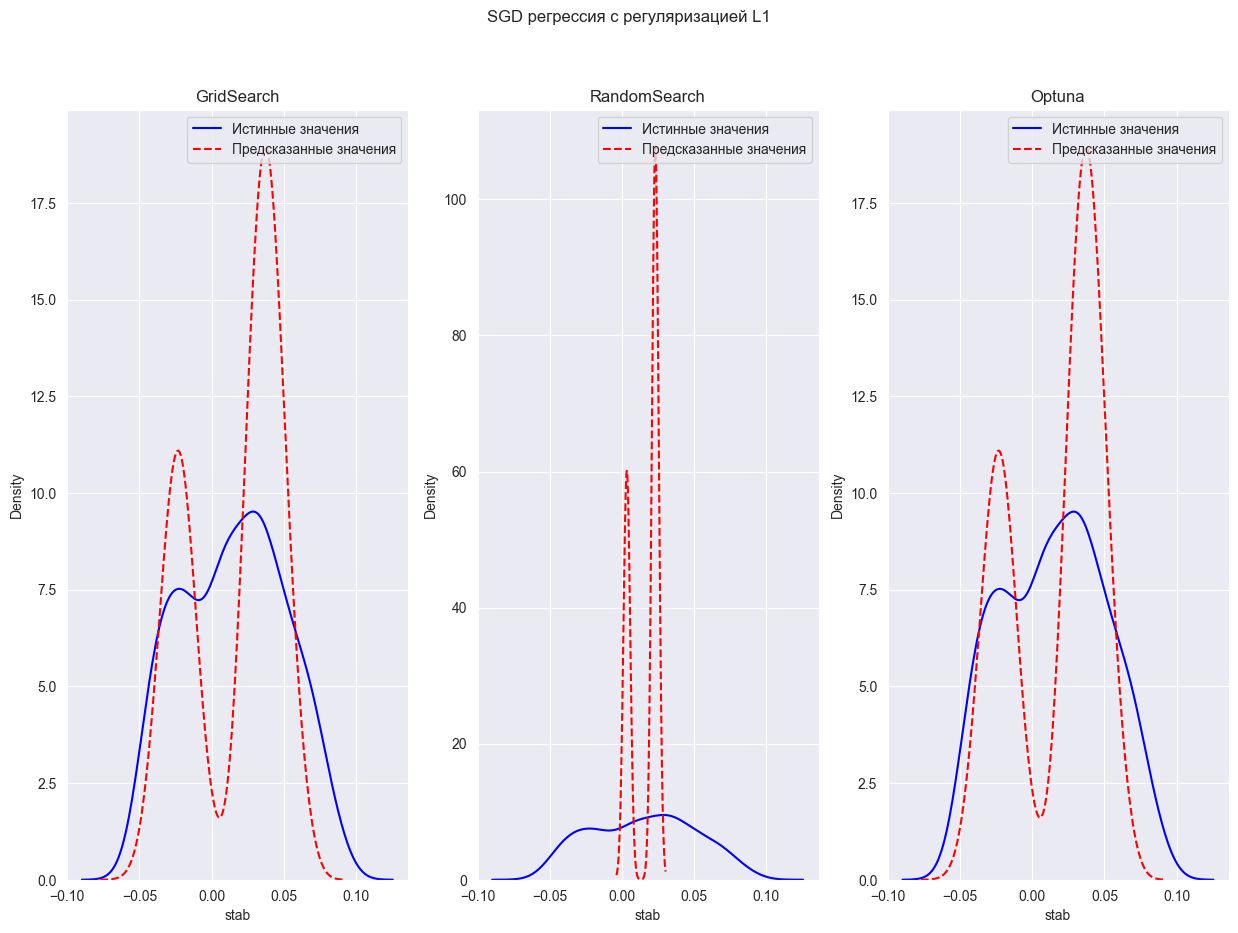

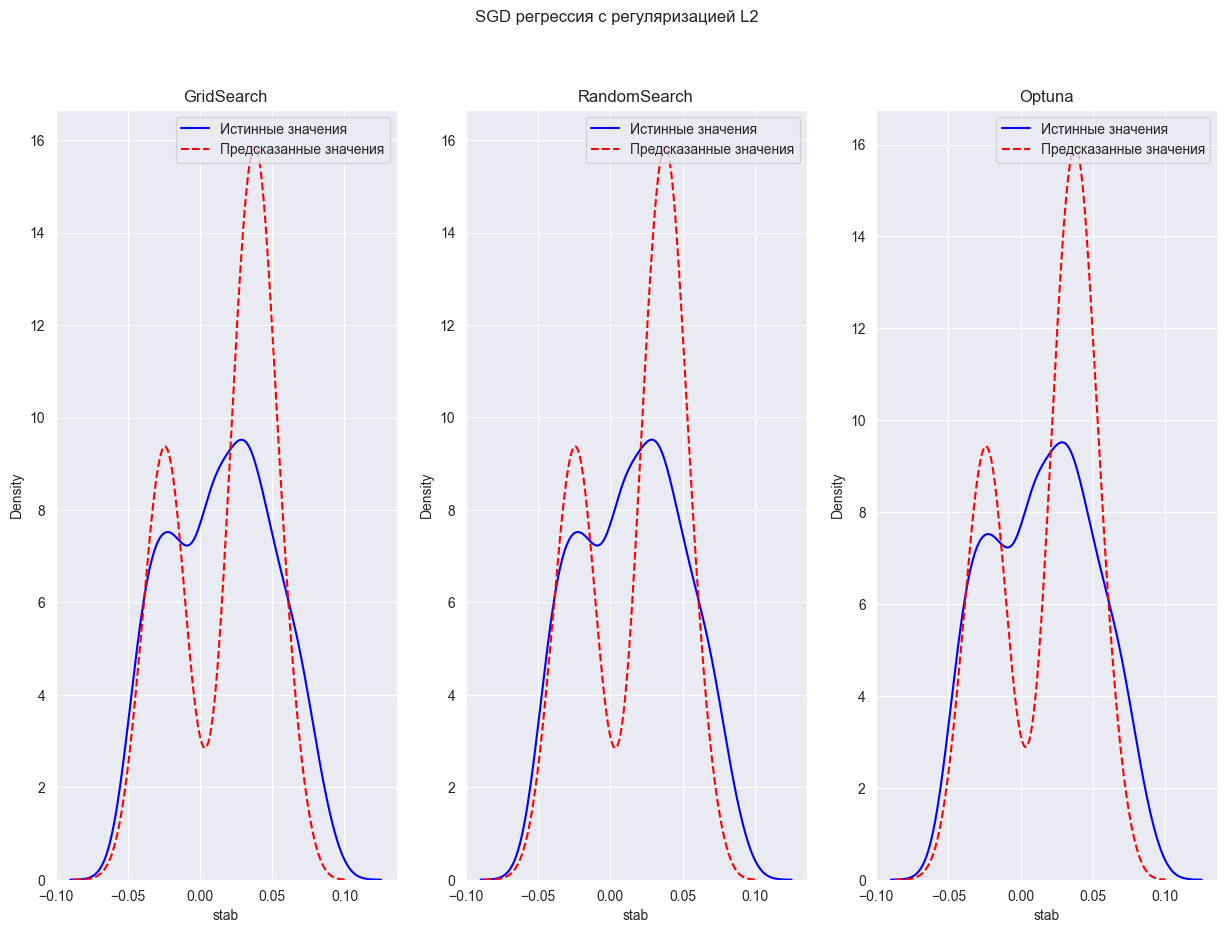

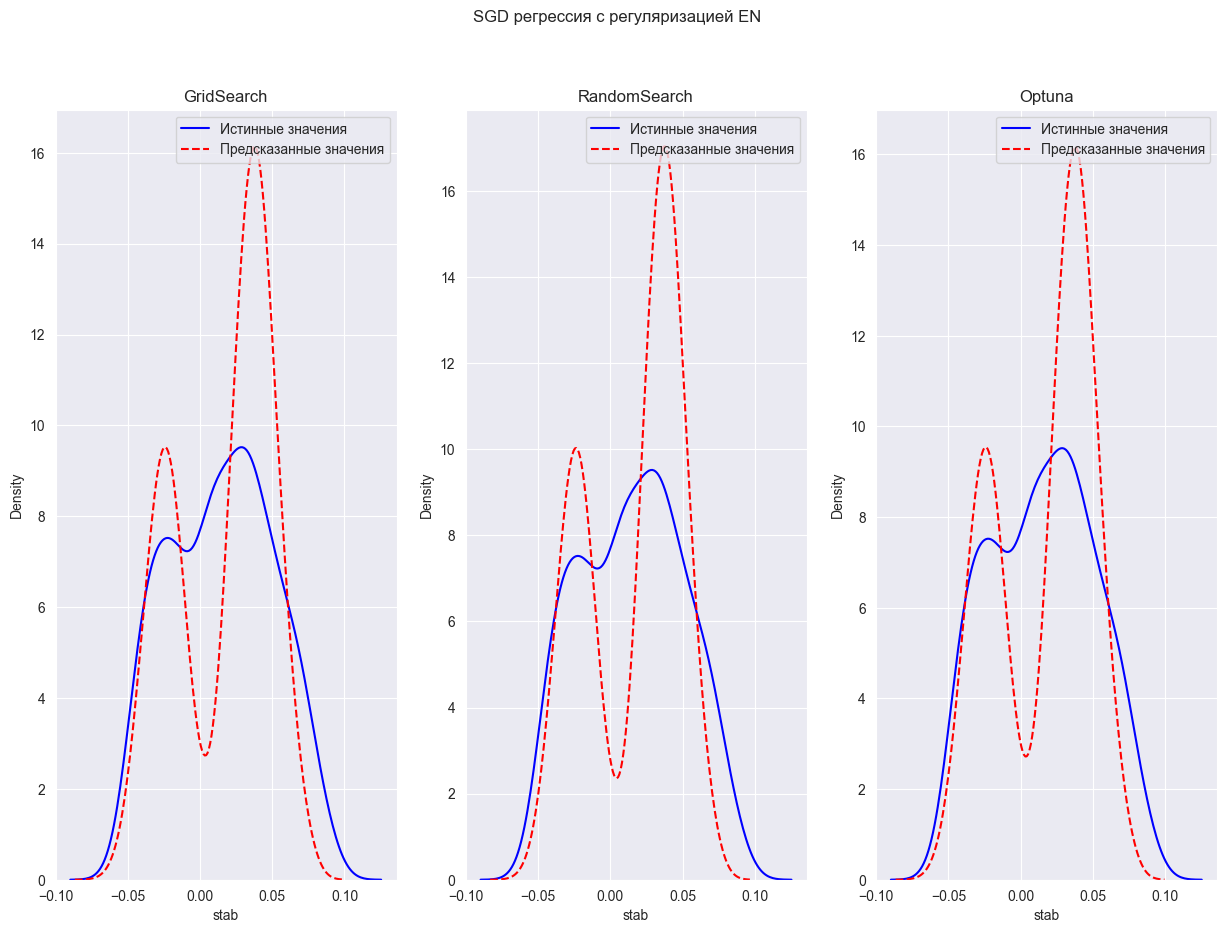

In [195]:
sgd_config = {"SGD": {
        "reg": SGDRegressor,
        "param_grid": {
            "penalty": ["l1", "l2", "elasticnet"],
            "alpha": alpha_range,
            "l1_ratio": [0.1, 0.5, 0.7],
            "learning_rate": ["constant", "adaptive"],
            "eta0": [0.001, 0.01],
            "max_iter": [1000],
        }
    }
}
sdg_models = train_models_with_reg(X_train, y_train, X_val, y_val, reg_config)

for name_of_reg, reg_info in sdg_models.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 10))
    for (name_of_method, model_info), ax in zip(reg_info.items(), axes):
        model = model_info["model"]
        name = f"SGD regression with {name_of_reg} ({name_of_method})"

        val_predict = model.predict(X_val)
        train_predict = model.predict(X_train)
        test_predict = model.predict(X_test)

        pipelines[name] = model

        input_metrics_into_the_train_val_table(name,
                          train_predict, y_train,
                          val_predict, y_val)

        input_metrics_into_the_test_table(name, test_predict, y_test)

        sns.kdeplot(y_val, color="blue", label="Истинные значения", ax=ax)

        sns.kdeplot(val_predict, linestyle="--", color="red", label="Предсказанные значения", ax=ax)

        ax.grid(True)
        ax.legend()
        ax.set_title(name_of_method)

    plt.suptitle(f"SGD регрессия c регуляризацией {name_of_reg}")


In [209]:
train_and_val_metrics_comparing[train_and_val_metrics_comparing.index.str.startswith("SGD")]

Train Data                          \
                                              R2     MSE    RMSE     MAE   
SGD regression                              0.82  0.0003  0.0159  0.0126   
SGD regression with L1 (GridSearch)         0.81  0.0003  0.0161  0.0129   
SGD regression with L1 (RandomSearch)       0.36  0.0009  0.0297  0.0245   
SGD regression with L1 (Optuna)             0.81  0.0003  0.0161  0.0129   
SGD regression with L2 (GridSearch)         0.82  0.0003  0.0158  0.0126   
SGD regression with L2 (RandomSearch)       0.82  0.0003  0.0158  0.0126   
SGD regression with L2 (Optuna)             0.82  0.0003  0.0158  0.0126   
SGD regression with EN (GridSearch)         0.82  0.0003  0.0158  0.0126   
SGD regression with EN (RandomSearch)       0.82  0.0003  0.0159  0.0127   
SGD regression with EN (Optuna)             0.82  0.0003  0.0158  0.0126   

                                               Val Data                  \
                                          MAPE       R2     MSE    RMSE   
SGD regression                         13.0081     0.81  0.0002  0.0156   
SGD regression with L1 (GridSearch)    14.2074     0.81  0.0002  0.0158   
SGD regression with L1 (RandomSearch)  13.1111     0.36  0.0008  0.0289   
SGD regression with L1 (Optuna)        14.2082     0.81  0.0002  0.0158   
SGD regression with L2 (GridSearch)    12.8719     0.82  0.0002  0.0155   
SGD regression with L2 (RandomSearch)  12.8733     0.82  0.0002  0.0155   
SGD regression with L2 (Optuna)        12.8258     0.82  0.0002  0.0155   
SGD regression with EN (GridSearch)    13.0330     0.82  0.0002  0.0155   
SGD regression with EN (RandomSearch)  13.4133     0.81  0.0002  0.0156   
SGD regression with EN (Optuna)        13.0500     0.82  0.0002  0.0155   

                                                       
                                          MAE    MAPE  
SGD regression                         0.0125  7.1294  
SGD regression with L1 (GridSearch)    0.0128  8.5576  
SGD regression with L1 (RandomSearch)  0.0239  3.4552  
SGD regression with L1 (Optuna)        0.0128  8.5581  
SGD regression with L2 (GridSearch)    0.0125  7.6821  
SGD regression with L2 (RandomSearch)  0.0125  7.6863  
SGD regression with L2 (Optuna)        0.0125  7.5446  
SGD regression with EN (GridSearch)    0.0125  7.7123  
SGD regression with EN (RandomSearch)  0.0126  7.9566  
SGD regression with EN (Optuna)        0.0125  7.7244

Настройка гиперпараметров никак не повлияла на качество модели с SGD регрессией.

In [211]:
train_and_val_metrics_comparing.sort_values(by=("Val Data", "R2"), ascending=False)

Train Data                  \
                                                           R2     MSE    RMSE   
Polynomial regression (deg = 4)                          0.98  0.0000  0.0049   
Polynomial regression (deg = 4) with EN (GridSe...       0.97  0.0000  0.0063   
Polynomial regression (deg = 4) with L2 (GridSe...       0.98  0.0000  0.0049   
Polynomial regression (deg = 4) with L2 (Random...       0.98  0.0000  0.0049   
Polynomial regression (deg = 4) with L2 (Optuna)         0.98  0.0000  0.0049   
Polynomial regression (deg = 3) with L2 (GridSe...       0.97  0.0000  0.0068   
Polynomial regression (deg = 3) with L2 (Random...       0.97  0.0000  0.0068   
Polynomial regression (deg = 3) with L2 (Optuna)         0.97  0.0000  0.0068   
Polynomial regression (deg = 3) with EN (GridSe...       0.96  0.0001  0.0072   
Polynomial regression (deg = 3) with EN (Optuna)         0.96  0.0001  0.0072   
Polynomial regression (deg = 4) with EN (Optuna)         0.97  0.0000  0.0065   
Polynomial regression (deg = 3)                          0.97  0.0000  0.0068   
Polynomial regression (deg = 3) with EN (Random...       0.94  0.0001  0.0091   
Polynomial regression (deg = 2) with L2 (GridSe...       0.93  0.0001  0.0101   
Polynomial regression (deg = 4) with EN (Random...       0.94  0.0001  0.0092   
Polynomial regression (deg = 2)                          0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with L2 (Random...       0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with EN (GridSe...       0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with EN (Optuna)         0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with L2 (Optuna)         0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with EN (Random...       0.92  0.0001  0.0107   
Polynomial regression (deg = 2) with L1 (GridSe...       0.90  0.0001  0.0120   
Polynomial regression (deg = 2) with L1 (Optuna)         0.90  0.0001  0.0120   
Polynomial regression (deg = 3) with L1 (Optuna)         0.89  0.0001  0.0122   
Polynomial regression (deg = 4) with L1 (GridSe...       0.89  0.0001  0.0122   
Polynomial regression (deg = 3) with L1 (GridSe...       0.89  0.0001  0.0122   
Polynomial regression (deg = 4) with L1 (Optuna)         0.89  0.0001  0.0122   
Multiple regression with L2 (RandomSearch)               0.82  0.0003  0.0158   
Multiple regression                                      0.82  0.0003  0.0158   
Multiple regression with L2 (Optuna)                     0.82  0.0003  0.0158   
SGD regression with EN (Optuna)                          0.82  0.0003  0.0158   
Multiple regression with EN (Optuna)                     0.82  0.0003  0.0158   
Multiple regression with EN (GridSearch)                 0.82  0.0003  0.0158   
Multiple regression with L2 (GridSearch)                 0.82  0.0003  0.0158   
SGD regression with EN (GridSearch)                      0.82  0.0003  0.0158   
SGD regression with L2 (Optuna)                          0.82  0.0003  0.0158   
SGD regression with L2 (GridSearch)                      0.82  0.0003  0.0158   
SGD regression with L2 (RandomSearch)                    0.82  0.0003  0.0158   
Multiple regression with L1 (GridSearch)                 0.81  0.0003  0.0161   
SGD regression with L1 (Optuna)                          0.81  0.0003  0.0161   
Multiple regression with EN (RandomSearch)               0.82  0.0003  0.0159   
Multiple regression with L1 (Optuna)                     0.81  0.0003  0.0161   
SGD regression with EN (RandomSearch)                    0.82  0.0003  0.0159   
SGD regression                                           0.82  0.0003  0.0159   
SGD regression with L1 (GridSearch)                      0.81  0.0003  0.0161   
Polynomial regression (deg = 3) with L1 (Random...       0.50  0.0007  0.0262   
Polynomial regression (deg = 4) with L1 (Random...       0.51  0.0007  0.0260   
Multiple regression with L1 (RandomSearch)               0.36  0.0009  0.0297   
P

In [206]:
test_metrics_info.sort_values(by=("Test Data", "R2"), ascending=False)

Test Data                  \
                                                          R2     MSE    RMSE   
Polynomial regression (deg = 3)                         0.96  0.0001  0.0075   
Polynomial regression (deg = 4)                         0.96  0.0001  0.0074   
Polynomial regression (deg = 4) with L2 (GridSe...      0.96  0.0001  0.0074   
Polynomial regression (deg = 4) with L2 (Random...      0.96  0.0001  0.0074   
Polynomial regression (deg = 4) with L2 (Optuna)        0.96  0.0001  0.0074   
Polynomial regression (deg = 3) with EN (Optuna)        0.96  0.0001  0.0076   
Polynomial regression (deg = 3) with L2 (Random...      0.96  0.0001  0.0075   
Polynomial regression (deg = 3) with L2 (Optuna)        0.96  0.0001  0.0075   
Polynomial regression (deg = 4) with EN (Optuna)        0.96  0.0001  0.0073   
Polynomial regression (deg = 4) with EN (GridSe...      0.96  0.0001  0.0072   
Polynomial regression (deg = 3) with EN (GridSe...      0.96  0.0001  0.0076   
Polynomial regression (deg = 3) with L2 (GridSe...      0.96  0.0001  0.0075   
Polynomial regression (deg = 3) with EN (Random...      0.93  0.0001  0.0095   
Polynomial regression (deg = 4) with EN (Random...      0.93  0.0001  0.0097   
Polynomial regression (deg = 2) with L2 (GridSe...      0.92  0.0001  0.0101   
Polynomial regression (deg = 2)                         0.92  0.0001  0.0101   
Polynomial regression (deg = 2) with L2 (Random...      0.92  0.0001  0.0101   
Polynomial regression (deg = 2) with EN (GridSe...      0.92  0.0001  0.0102   
Polynomial regression (deg = 2) with EN (Optuna)        0.92  0.0001  0.0102   
Polynomial regression (deg = 2) with L2 (Optuna)        0.92  0.0001  0.0101   
Polynomial regression (deg = 2) with EN (Random...      0.91  0.0001  0.0110   
Polynomial regression (deg = 2) with L1 (GridSe...      0.89  0.0002  0.0123   
Polynomial regression (deg = 2) with L1 (Optuna)        0.89  0.0002  0.0123   
Polynomial regression (deg = 3) with L1 (Optuna)        0.88  0.0002  0.0125   
Polynomial regression (deg = 4) with L1 (GridSe...      0.88  0.0002  0.0125   
Polynomial regression (deg = 3) with L1 (GridSe...      0.88  0.0002  0.0125   
Polynomial regression (deg = 4) with L1 (Optuna)        0.88  0.0002  0.0125   
Multiple regression with L2 (RandomSearch)              0.80  0.0003  0.0165   
Multiple regression                                     0.80  0.0003  0.0165   
Multiple regression with L2 (Optuna)                    0.80  0.0003  0.0164   
Multiple regression with EN (RandomSearch)              0.80  0.0003  0.0165   
Multiple regression with EN (Optuna)                    0.80  0.0003  0.0164   
Multiple regression with EN (GridSearch)                0.80  0.0003  0.0164   
Multiple regression with L2 (GridSearch)                0.80  0.0003  0.0165   
SGD regression with EN (Optuna)                         0.80  0.0003  0.0164   
SGD regression with L2 (Optuna)                         0.80  0.0003  0.0164   
SGD regression with EN (GridSearch)                     0.80  0.0003  0.0164   
SGD regression with L2 (RandomSearch)                   0.80  0.0003  0.0165   
SGD regression with EN (RandomSearch)                   0.80  0.0003  0.0165   
SGD regression with L2 (GridSearch)                     0.80  0.0003  0.0165   
SGD regression                                          0.80  0.0003  0.0165   
Multiple regression with L1 (GridSearch)                0.79  0.0003  0.0166   
SGD regression with L1 (Optuna)                         0.79  0.0003  0.0166   
SGD regression with L1 (GridSearch)                     0.79  0.0003  0.0166   
Multiple regression with L1 (Optuna)                    0.79  0.0003  0.0166   
Polynomial regression (deg = 4) with L1 (Random...      0.51  0.0007  0.0256   
Polynomial regression (deg = 3) with L1 (Random...      0.50  0.0007  0.0257   
Multiple regression with L1 (RandomSearch)              0.36  0.0009  0.0292   
Polynomial regression (deg = 2) with L1 (Random... 

Лучшей моделью на валидационных данных оказалась полиномиальная регрессия 4 степени без регуляризации.

Для этой модели были получены следующие значения метрик:

* R2 = 0.96
* MSE = 0.0001
* RMSE = 0.0074
* MAE = 0.0049
* MAPE = 0.5891

Стоит отметить, что метрики R2, MSE, RMSE, MAE на тестовых данных для модели 4 степени без регуляризации и модели 3 степени без регуляризации практически не отличаются.

Сравним результаты с моделью, полученной в ходе практической работы № 3.

In [212]:
practice3_results.sort_values(by=("Test Data", "R2"), ascending=False)

Train Data                  \
                                                           R2     MSE    RMSE   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0208  0.1442   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0209  0.1445   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0225  0.1501   
Polynomial regression (deg 4) with L2 (Optuna)           0.98   0.018  0.1343   
Polynomial regression (deg 4) with L2 (GridSearch)       0.98  0.0181  0.1346   
Polynomial regression (deg 4) with L1 (Optuna)           0.98  0.0231  0.1519   
Polynomial regression (deg 4) without regulariz...       0.98   0.018  0.1343   
Polynomial regression (deg 4) with L1 (GridSearch)       0.98  0.0231  0.1519   
Polynomial regression (deg 3) with L1 (Optuna)           0.97  0.0349  0.1869   
Polynomial regression (deg 4) with L2 (RandomSe...       0.98  0.0182   0.135   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0339  0.1841   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0345  0.1858   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0344  0.1854   
Polynomial regression (deg 3) with L2 (Optuna)           0.97  0.0335  0.1832   
Polynomial regression (deg 3) with L2 (RandomSe...       0.97  0.0335  0.1832   
Polynomial regression (deg 3) with L2 (GridSearch)       0.97  0.0336  0.1832   
Polynomial regression (deg 3) with L1 (GridSearch)       0.97  0.0349  0.1869   
Polynomial regression (deg 3) without regulariz...       0.97  0.0335  0.1832   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0726  0.2695   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0726  0.2695   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression(deg 2) with L1 (get with ...       0.93  0.0727  0.2697   
Polynomial regression (deg 2) without regulariz...       0.93  0.0725  0.2692   
Polynomial regression(deg 2) with L1 (get with ...       0.93  0.0727  0.2697   
Polynomial regression (deg 3) with L1 (RandomSe...       0.92  0.0814  0.2853   
Polynomial regression (deg 4) with L1 (RandomSe...       0.91    0.09     0.3   
Polynomial regression(deg 2) with L1 (get with ...       0.91  0.0921  0.3035   
Linear regression with Lasso regularization              0.82  0.1841  0.4291   
Linear regression with Elastic Net (get with Op...       0.82  0.1843  0.4293   
Linear regression with Elastic Net (get with Ra...       0.82  0.1841   0.429   
Linear regression with Elastic Net (get with Gr...       0.82  0.1841   0.429   
Linear regression with Ridge regularization              0.82  0.1843  0.4293   
Linear regression without regularization                 0.82   0.184  0.4289   

                                                                   Test Data  \
                                                       MAE    MAPE        R2   
Polynomial regression (deg 4) with Elastic Net ...   0.098  0.3674      0.97   
Polynomial regression (deg 4) with Elastic Net ...  0.0992  0.3667      0.97   
Polynomial regression (deg 4) with Elastic Net ...  0.1023    0.38      0.97   
Polynomial regression (deg 4) with L2 (Optuna)      0.0921  0.3408      0.97   
Polynomial regression (deg 4) with L2 (GridSearch)  0.0923  0.3376      0.97   
Polynomial regression (deg 4) with L1 (Optuna)      0.1037  0.3863      0.97   
Polynomial regression (deg 4) without regulariz...  0.0921  0.3423      0.97   
Polynomial regression (deg 4) with L1 (GridSearch)  0.1036  0.3862      0.97   
Polynomial regression (deg 3) with L1 (Optuna)      0.1311  0.5809      0.96   
Polynomial regression (deg 4) with L2 (RandomSe...  0.0926  0.3374      0.96   
Polynomial r

В результате практической работы номер 3 лучшей моделью была выбрана модель с L1 регуляризацией (параметры были получены с помощью Optuna).

Заметим, что значения метрик MSE, RMSE, MAE сильно отличаются от метрик в текущей работе. Это связано с использованием пайплайнов в текущей работе. При этом коэффициенты R2 оказались примерно схожи - 0.97 и 0.96.

В двух работах лучшими моделями оказались модели с полиномиальной регрессией 4 степени. Это говорит о сложных зависимостях в данных.

## Сохранение данных в файлы

Сохраним данные в файлы

In [199]:
train_df = pd.concat([X_train, y_train], axis=1)
val_df = pd.concat([X_val, y_val], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

PATH = os.getcwd()
train_path = os.path.join(PATH, "trainR.csv")
val_path = os.path.join(PATH, "valR.csv")
test_path = os.path.join(PATH, "testR.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

Прочитаем данные из файлов

In [200]:
train_df = pd.read_csv("trainR.csv")
val_df = pd.read_csv("valR.csv")
test_df = pd.read_csv("testR.csv")

X_train, y_train = train_df.drop("stab", axis=1), train_df["stab"]
X_val, y_val = val_df.drop("stab", axis=1), val_df["stab"]
X_test, y_test = test_df.drop("stab", axis=1), test_df["stab"]

print(f"Количество объектов в общей выборке: {len(X)}\n"
      f"Количество объектов в тренировочной выборке: {len(X_train)}\n"
      f"Количество объектов в валидационной выборке: {len(X_val)}\n"
      f"Количество объектов в тестовой выборке: {len(X_test)}")

Количество объектов в общей выборке: 10000
Количество объектов в тренировочной выборке: 8000
Количество объектов в валидационной выборке: 1000
Количество объектов в тестовой выборке: 1000


In [201]:
file_data_columns = pd.MultiIndex.from_product([["Train Data", "Val Data", "Test Data"], metrics])
file_data_results = pd.DataFrame(columns=file_data_columns)
file_data_results

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Val Data, R2), (Val Data, MSE), (Val Data, RMSE), (Val Data, MAE), (Val Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

In [202]:
def input_metrics_into_the_train_val_test_table(name_of_model,
                          predict_on_train, y_train,
                          predict_on_val, y_val,
                          predict_on_test, y_test):
    val_metrics = get_metrics(y_val, predict_on_val)

    train_metrics = get_metrics(y_train, predict_on_train)

    test_metrics = get_metrics(y_test, predict_on_test)

    file_data_results.loc[name_of_model] = train_metrics  + val_metrics + test_metrics

In [203]:
for name_of_model, pipeline in pipelines.items():
    predict_on_train = pipeline.predict(X_train)

    predict_on_val = pipeline.predict(X_val)

    predict_on_test = pipeline.predict(X_test)

    input_metrics_into_the_train_val_test_table(name_of_model,
                          predict_on_train, y_train,
                          predict_on_val, y_val,
                          predict_on_test, y_test)

In [204]:
file_data_results.sort_values(by=("Test Data", "R2"), ascending=False)

Train Data                  \
                                                           R2     MSE    RMSE   
Polynomial regression (deg = 3)                          0.97  0.0000  0.0068   
Polynomial regression (deg = 4)                          0.98  0.0000  0.0049   
Polynomial regression (deg = 4) with L2 (GridSe...       0.98  0.0000  0.0049   
Polynomial regression (deg = 4) with L2 (Random...       0.98  0.0000  0.0049   
Polynomial regression (deg = 4) with L2 (Optuna)         0.98  0.0000  0.0049   
Polynomial regression (deg = 3) with EN (Optuna)         0.96  0.0001  0.0072   
Polynomial regression (deg = 3) with L2 (Random...       0.97  0.0000  0.0068   
Polynomial regression (deg = 3) with L2 (Optuna)         0.97  0.0000  0.0068   
Polynomial regression (deg = 4) with EN (Optuna)         0.97  0.0000  0.0065   
Polynomial regression (deg = 4) with EN (GridSe...       0.97  0.0000  0.0063   
Polynomial regression (deg = 3) with EN (GridSe...       0.96  0.0001  0.0072   
Polynomial regression (deg = 3) with L2 (GridSe...       0.97  0.0000  0.0068   
Polynomial regression (deg = 3) with EN (Random...       0.94  0.0001  0.0091   
Polynomial regression (deg = 4) with EN (Random...       0.94  0.0001  0.0092   
Polynomial regression (deg = 2) with L2 (GridSe...       0.93  0.0001  0.0101   
Polynomial regression (deg = 2)                          0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with L2 (Random...       0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with EN (GridSe...       0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with EN (Optuna)         0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with L2 (Optuna)         0.93  0.0001  0.0101   
Polynomial regression (deg = 2) with EN (Random...       0.92  0.0001  0.0107   
Polynomial regression (deg = 2) with L1 (GridSe...       0.90  0.0001  0.0120   
Polynomial regression (deg = 2) with L1 (Optuna)         0.90  0.0001  0.0120   
Polynomial regression (deg = 3) with L1 (Optuna)         0.89  0.0001  0.0122   
Polynomial regression (deg = 4) with L1 (GridSe...       0.89  0.0001  0.0122   
Polynomial regression (deg = 3) with L1 (GridSe...       0.89  0.0001  0.0122   
Polynomial regression (deg = 4) with L1 (Optuna)         0.89  0.0001  0.0122   
Multiple regression with L2 (RandomSearch)               0.82  0.0003  0.0158   
Multiple regression                                      0.82  0.0003  0.0158   
Multiple regression with L2 (Optuna)                     0.82  0.0003  0.0158   
Multiple regression with EN (RandomSearch)               0.82  0.0003  0.0159   
Multiple regression with EN (Optuna)                     0.82  0.0003  0.0158   
Multiple regression with EN (GridSearch)                 0.82  0.0003  0.0158   
Multiple regression with L2 (GridSearch)                 0.82  0.0003  0.0158   
SGD regression with EN (Optuna)                          0.82  0.0003  0.0158   
SGD regression with L2 (Optuna)                          0.82  0.0003  0.0158   
SGD regression with EN (GridSearch)                      0.82  0.0003  0.0158   
SGD regression with L2 (RandomSearch)                    0.82  0.0003  0.0158   
SGD regression with EN (RandomSearch)                    0.82  0.0003  0.0159   
SGD regression with L2 (GridSearch)                      0.82  0.0003  0.0158   
SGD regression                                           0.82  0.0003  0.0159   
Multiple regression with L1 (GridSearch)                 0.81  0.0003  0.0161   
SGD regression with L1 (Optuna)                          0.81  0.0003  0.0161   
SGD regression with L1 (GridSearch)                      0.81  0.0003  0.0161   
Multiple regression with L1 (Optuna)                     0.81  0.0003  0.0161   
Polynomial regression (deg = 4) with L1 (Random...       0.51  0.0007  0.0260   
Polynomial regression (deg = 3) with L1 (Random...       0.50  0.0007  0.0262   
Multiple regression with L1 (RandomSearch)               0.36  0.0009  0.0297   
P

Результаты при чтении данных из файла совпали с результатами при хранении данных в локальных переменных.

## Вывод

В результате выполнения практической работы № 4 лучшей моделью на тестовых данных оказалась модель полиномиальной регрессии 4 степени без регуляризации.

В результате практической работы номер 3 лучшей моделью была выбрана модель с L1 регуляризацией (параметры были получены с помощью Optuna).

Коэффициенты R2 оказались примерно схожи - 0.97 на модели с L1 регуляризацией и 0.96 с моделью полиномиальной регрессии 4 степени без регуляризации. Таким образом, нельзя сказать о том, что использование валидационной выборки при обучении оказало сильное влияние на улучшение показателей метрик.

В двух работах лучшими моделями оказались модели с полиномиальной регрессией 4 степени. Это говорит о сложных зависимостях в данных.

